# Equal1 State Tomography Trial

The aim of this notebook is to implement the procedures to simulate standard indirect quantum state tomography and QELM state tomography on the inaccessible register qubit in the hardware produced by Equal1. The goal is to establish if QELM state tomography can out-perform the standard indirect procedure and if so, what the requirements on training data are to overcome the inaccuracies associated with state preparation.

## 1. Imports

In [298]:
from plot_format import setup_mpl

In [299]:
setup_mpl()

In [300]:
import numpy as np
import scipy
import copy
from qutip import Bloch
#from sklearn.linear_model import LinearRegression
from qres.regression import LinearRegression



from qsim.lin_alg import sigmaX, sigmaY, sigmaZ, Operator, I

from qsim.state import DensityMatrix, POVMDetector

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import scipy.optimize
from itertools import product
from functools import reduce

## 2. Model Setup

In [301]:
noise_active = True
save = False

if noise_active:
    lambda_dep_1 = 1* 0.001 *1.33 * 3 / 2
    lambda_dep_2 = 0.005 * (4/3) * (15 / 16)*1.06
    rot_noise_1 = 0#0.063
    rot_noise_2 = 0#0.111
    thermal_noise = 0.56#0.56
else:
    lambda_dep_1 = 0
    lambda_dep_2 = 0
    rot_noise_1 = 0#0.063
    rot_noise_2 = 0#0.111
    thermal_noise = 0

In [302]:
H = Operator(np.array([[1,1],[1,-1]])/(2**0.5))
S = Operator(np.array([[1,0],[0,1j]]))
CNOT = Operator(np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]]))

In [303]:
def sqrt_density_matrix(rho):
    vals, vecs = np.linalg.eigh(rho)

    # Clip tiny negatives from numerical noise
    vals = np.clip(vals, 0, None)

    sqrt_vals = np.sqrt(vals)
    return vecs @ np.diag(sqrt_vals) @ vecs.conj().T

In [304]:
from scipy.stats import unitary_group

def haar_random_unitary(N):
    return unitary_group.rvs(N)

In [305]:
def generateParameterisedRotation(U: Operator, epsilon: float) -> Operator:
    U_herm = 0.5 * (U + U.hConj())
    return Operator(scipy.linalg.expm(-1j*epsilon*U_herm.matrix))

In [306]:
def generateNoisyGate(gate: Operator, epsilon: float) -> Operator:
    U = Operator(haar_random_unitary(gate.matrix.shape[0]))
    U_herm = 0.5 * (U + U.hConj())
    return Operator(scipy.linalg.expm(-1j*epsilon*U_herm.matrix)) @ gate

def generateDepolarisingChannel(sites: list, epsilon: float) -> callable:
    paulis = [I(2), sigmaX, sigmaY, sigmaZ]
    pauli_strings = [reduce(lambda x,y: x^y, p_string).changeHilbertSpace((2,2,2), send_to_sites=sites, base_dims=(2,)*len(sites)) for p_string in list(product(paulis, repeat=len(sites)))]

    def dep_channel(state: DensityMatrix) -> DensityMatrix:
        return (1-epsilon) * state + epsilon * reduce(lambda x, y: x+y, [p @ state @ p.hConj() for p in pauli_strings]) / len(pauli_strings)
    return dep_channel


def generateDepolarisingChannelHeisenberg(sites, epsilon: float) -> callable:
    remaining_sites = []
    for site in range(3):
        if site not in sites:
            remaining_sites.append(site)

    remaining_sites = tuple(remaining_sites)
    def dep_channel(op: DensityMatrix) -> DensityMatrix:
        return (1-epsilon) * op + epsilon * op.partialTrace((2,2,2), remaining_sites).changeHilbertSpace((2,2,2), send_to_sites=remaining_sites, base_dims=(2,) * len(remaining_sites)) / (2**len(sites))
    return dep_channel

def generateDepolarisingChannelHeisenberg3(epsilon: float) -> callable:
    def dep_channel(op: DensityMatrix) -> DensityMatrix:
        return (1-epsilon) * op + epsilon * I(2).tensor(op.partialTrace((2,2,2), (1,2))) / 2
    return dep_channel

def generateDepolarisingChannelHeisenberg2(epsilon: float) -> callable:
    def dep_channel(op: DensityMatrix) -> DensityMatrix:
        return (1-epsilon) * op + epsilon * I(4).tensor(op.partialTrace((2,2,2), (2,))) / 4
    return dep_channel

In [307]:
def controlRotationGate(gate):
    return (Operator(np.array([[1,0],[0,0]])) ^ I(2)) + (Operator(np.array([[0,0],[0,1]])) ^ gate)

In [308]:
def gateFidelity(gate1: Operator, gate2: Operator) -> float:
    d=gate1.matrix.shape[0]
    return (np.abs((gate1.hConj() @ gate2).trace())**2 + d)/(d**2 + d)

In [309]:
r_u = channel(Operator(haar_random_unitary(2)))
dep_chan = generateDepolarisingChannel((0,), lambda_dep_1*1.33)
s= DensityMatrix(np.array([[1,0],[0,0]]))

In [310]:
fidelity(dep_chan(r_u(s).tensor(DensityMatrix(np.array([[1,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]])))).partialTrace((2,2,2),(0,)), r_u(s))

np.float64(0.9986733366450448)

In [311]:
gate = Operator(np.eye(2))
gate=sigmaX
strengths = np.linspace(0, np.pi/20, 200)

fids1 = []
vars1 = []

for strength in strengths:
    noisy_gates = [generateNoisyGate(gate, strength) for i in range(100)]
    gate_fids = [gateFidelity(gate, noisy_gate) for noisy_gate in noisy_gates]
    fids1.append(np.mean(gate_fids))
    vars1.append(np.std(gate_fids))



In [312]:
gate = Operator(np.eye(2))
gate=sigmaX.tensor(sigmaX)
strengths = np.linspace(0, np.pi/20, 200)

fids2 = []
vars2 = []

for strength in strengths:
    noisy_gates = [generateNoisyGate(gate, strength) for i in range(100)]
    gate_fids = [gateFidelity(gate, noisy_gate) for noisy_gate in noisy_gates]
    fids2.append(np.mean(gate_fids))
    vars2.append(np.std(gate_fids))



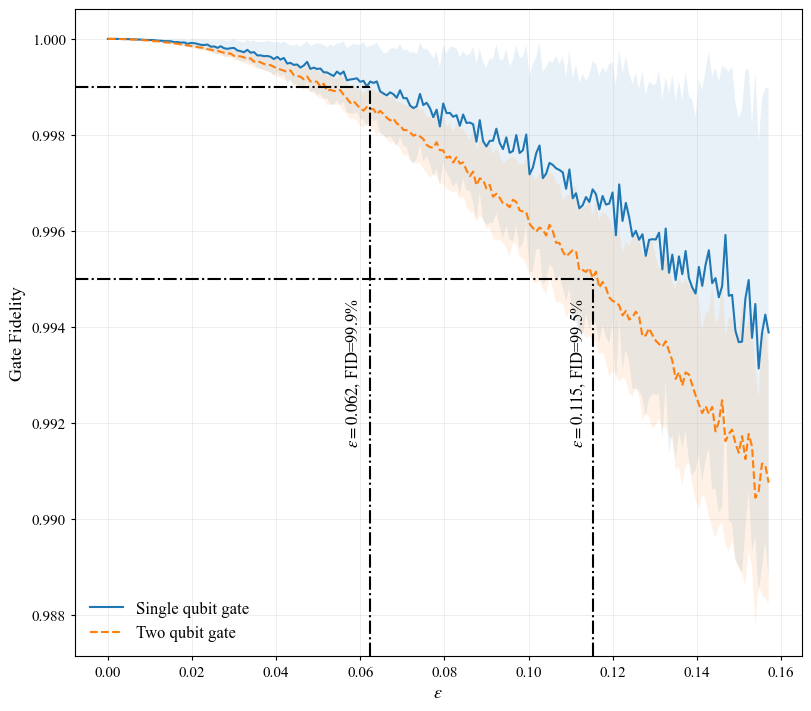

In [313]:
fig, ax1 = plt.subplots(ncols=1, dpi=100, figsize=(8,7))
ax1.plot(strengths, fids1, label='Single qubit gate')
ax1.fill_between(strengths, (np.array(fids1) - np.array(vars1)), (np.array(fids1) + np.array(vars1)), alpha=0.1)
ax1.set_xlabel(r'$\varepsilon$')
ax1.set_ylabel('Gate Fidelity')

ax1.plot(strengths, fids2, label='Two qubit gate')
ax1.fill_between(strengths, (np.array(fids2) - np.array(vars2)), (np.array(fids2) + np.array(vars2)), alpha=0.1)
ax1.set_xlabel(r'$\varepsilon$')
ax1.set_ylabel('Gate Fidelity')
ax1.text(x = 00.68, y=0.33, s=r'$\varepsilon = ' + str(np.round(strengths[146], 3)) + r'$, FID=99.5%', rotation=90, transform=ax1.transAxes)
ax1.text(x = 0.37,y=0.33, s=r'$\varepsilon = ' + str(np.round(strengths[79], 3)) + r'$, FID=99.9%', rotation=90, transform=ax1.transAxes)
ylims = ax1.get_ylim()
xlims = ax1.get_xlim()
ax1.vlines([strengths[79], strengths[146]], ymin=ax1.get_ylim()[0], ymax=[0.999,0.995], linestyle='-.', color='black')
ax1.hlines([0.999, 0.995], xmin=ax1.get_xlim()[0], xmax=[strengths[79], strengths[146]], color='k', linestyle='-.')
ax1.set_ylim(ylims)
ax1.set_xlim(xlims)
ax1.legend()
if save:
    fig.savefig("Plots/gate_fid.pdf")

In [314]:
def generateNoisyState(state: DensityMatrix, epsilon: float) -> DensityMatrix:
    U = Operator(haar_random_unitary(state.matrix.shape[0]))
    U_herm = 0.5 * (U + U.hConj())
    R = Operator(scipy.linalg.expm(-1j*epsilon*U_herm.matrix))
    return R @ state @ R.hConj()

def generateQubitRegister():
    return DensityMatrix(np.array([[1,0],[0,0]]))

def generateRegister():
    state = generateQubitRegister()
    return state ^ state ^ state

def generateNoisyRegister(epsilon: float) -> DensityMatrix:
    state = generateQubitRegister()
    state_noiy1 = generateNoisyState(state, epsilon)
    state_noiy2 = generateNoisyState(state, epsilon)
    state_noiy3 = generateNoisyState(state, epsilon)
    return state_noiy1 ^ state_noiy2 ^ state_noiy3

def generateThermalRegister(T: float) -> DensityMatrix:
    # 1. Handle strict absolute zero to avoid division by zero
    if T == 0.0:
        T = 1e-15 
        
    beta = 1.0 / T
    H = np.array([[-1, 0], [0, 1]])
    
    # 2. Shift the Hamiltonian by its minimum eigenvalue
    # This prevents exp(+inf) numerical overflows at low T
    min_energy = np.min(np.linalg.eigvalsh(H))
    shifted_H = H - (min_energy * np.eye(2))
    
    # 3. Apply the correct physical sign (-beta)
    unnormalized_state = scipy.linalg.expm(-beta * shifted_H)
    
    # Normalize 
    state_matrix = unnormalized_state / np.trace(unnormalized_state)
    
    # Cast to your custom DensityMatrix class and return the register
    state = DensityMatrix(state_matrix)
    return state ^ state ^ state

In [315]:
def fidelity(rho1, rho2):
    rho1_sqrt = sqrt_density_matrix(rho1.matrix)
    return np.abs(np.trace(sqrt_density_matrix(rho1_sqrt @ rho2.matrix @ rho1_sqrt)))**2


In [316]:
target_register = np.zeros((8,8))
target_register[0][0]=1
target_register = DensityMatrix(target_register)
strengths = np.linspace(0, np.pi/3, 100)

fids = []
lowers = []

for strength in tqdm(strengths):
    noisy_states = [generateNoisyRegister(strength) for i in range(100)]
    state_fids = [fidelity(target_register, state) for state in noisy_states]
    fids.append(np.mean(state_fids))
    lowers.append(np.std(state_fids))



  0%|          | 0/100 [00:00<?, ?it/s]

In [317]:
target_register = np.zeros((8,8))
target_register[0][0]=1
target_register = DensityMatrix(target_register)
temps = np.linspace(0.01, 1, 100)

fids2 = []

for T in tqdm(strengths[1:]):
    noisy_state = generateThermalRegister(T)
    state_fid = fidelity(target_register, noisy_state)
    fids2.append(state_fid)


  0%|          | 0/99 [00:00<?, ?it/s]

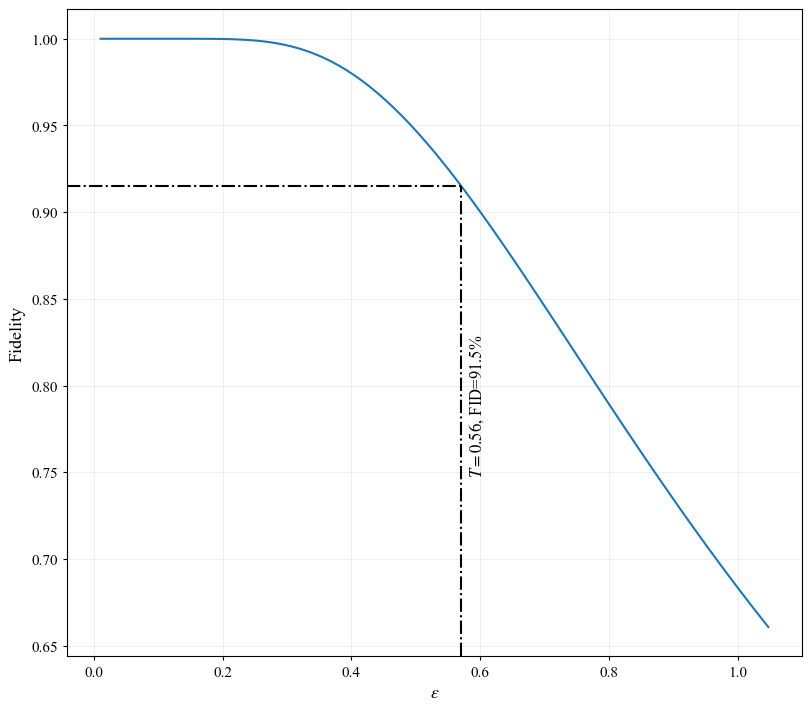

In [318]:
fig, ax = plt.subplots(ncols=1, dpi=100, figsize=(8,7))
ax.plot(strengths[1:], fids2, label='Thermal Register')
#ax.plot(strengths, fids, label='Noisy Pure Register')
#ax.fill_between(strengths, (np.array(fids) - np.array(vars)), (np.array(fids) + np.array(vars)), alpha=0.1, color='orange')
ax.set_xlabel(r'$\varepsilon$')
ax.set_ylabel('Fidelity')
ax.text(x = 0.58, y=0.75, s=r'$T = ' + str(np.round(temps[55], 3)) + r'$, FID=91.5%', rotation=90)
#ax.text(x = 0.35, y=0.35, s=r'$\varepsilon = ' + str(np.round(strengths[33], 3)) + r'$, FID=91.5%', rotation=90)
ylims = ax.get_ylim()
xlims = ax.get_xlim()
ax.vlines([temps[56]], ymin=ax.get_ylim()[0], ymax=0.915, linestyle='-.', color='black')
#ax.vlines([temps[56], strengths[32]*1.01], ymin=ax.get_ylim()[0], ymax=0.915, linestyle='-.', color='black')
ax.hlines(0.915, xmin=ax.get_xlim()[0], xmax=temps[56], color='k', linestyle='-.')
ax.set_ylim(ylims)
ax.set_xlim(xlims)
if save:
    fig.savefig("Plots/thermal_register_fid.pdf")

## 3. Indirect QST

Configure POVM with inaccurate readout

In [347]:
if noise_active:
    e0 = 0.01
    e1 = 0.03
else:
    e0 = 0
    e1 = 0

def generateNoisyPOVM(e0, e1):
    povm1 = Operator(np.array([[1-e0,0],[0,e1]]))
    povm2 = Operator(np.array([[e0,0],[0,1-e1]]))
    return povm1, povm2


Selecting the register preparation function that will be used to generate results, either noisy pure states or a fixed thermal state

In [320]:
if noise_active:
    def noisy_register_func():
        return generateNoisyRegister(0.349)

    def thermal_register_func():
        return generateThermalRegister(thermal_noise)
else:
    def noisy_register_func():
        return generateRegister()

    def thermal_register_func():
        return generateRegister()

Configuring circuits for performing standard tomography by measuring either the middle or right most qubit

In [321]:
def setupDetector(circ, target, e0, e1, shots=1):
    povm1, povm2 = generateNoisyPOVM(e0, e1)
    det = POVMDetector(povm=[povm1, povm2], outcomes=[1, -1], dims=(2,2,2), target_sites=(target,))
    def measure(state):
        return det.detect(circ @ state @ circ.hConj(), shots=shots)
    return measure

def setupJointDetector(circ, targets, e0, e1, shots=1):
    povm1, povm2 = generateNoisyPOVM(e0, e1)
    det = POVMDetector(povm=[povm1 ^ povm1, povm1 ^ povm2, povm2 ^ povm1, povm2 ^ povm2], outcomes=[1, -1, -1, 1], dims=(2,2,2), target_sites=targets)
    def measure(state):
        return det.detect(circ @ state @ circ.hConj(), shots=shots)
    return measure

def setupDetectorDepolarising(circ, target, e0, e1, shots=1):
    povm1, povm2 = generateNoisyPOVM(e0, e1)
    det = POVMDetector(povm=[povm1, povm2], outcomes=[1, -1], dims=(2,2,2), target_sites=(target,))
    def measure(state):
        return det.detect(circ(state), shots=shots)
    return measure

def setupJointDetectorDepolarising(circ, target, e0, e1, shots=1):
    povm1, povm2 = generateNoisyPOVM(e0, e1)
    det = POVMDetector(povm=[povm1 ^ povm1, povm1 ^ povm2, povm2 ^ povm1, povm2 ^ povm2], outcomes=[1, -1, -1, 1], dims=(2,2,2), target_sites=target)
    def measure(state):
        return det.detect(circ(state), shots=shots)
    return measure

def sigmaXgates(H, CNOT):
    circ = CNOT @ H.tensor(I(2))
    return circ.tensor(I(2))

def sigmaXgatesDepolarising(H, CNOT, lambda1, lambda2):
    gate1 = H.tensor(I(4))
    gate2 = CNOT ^ I(2)
    dep2 = generateDepolarisingChannel((0,1), lambda2)
    dep1 = generateDepolarisingChannel((0,), lambda1)
    def f(state: DensityMatrix) -> DensityMatrix:
        return dep2(gate2 @ dep1(gate1 @ state @ gate1.hConj()) @ gate2.hConj())
    return f

def sigmaXgatesDepolarisingReverse(H, CNOT, lambda1, lambda2, e0, e1):
    povm1, povm2 = generateNoisyPOVM(e0, e1)
    gate1 = H.tensor(I(4))
    gate2 = CNOT ^ I(2)
    dep1 = generateDepolarisingChannelHeisenberg((0,), lambda1)
    dep2 = generateDepolarisingChannelHeisenberg((0,1), lambda2)
    def f(state: DensityMatrix) -> DensityMatrix:
        return (state @ (gate1.hConj() @ dep1(gate2.hConj() @ dep2(I(2) ^ povm1 ^ I(2)) @ gate2) @ gate1 - gate1.hConj() @ dep1(gate2.hConj() @ dep2(I(2) ^ povm2 ^ I(2)) @ gate2) @ gate1)).trace()
    return f, gate1.hConj() @ dep1(gate2.hConj() @ dep2(I(2) ^ povm1 ^ I(2)) @ gate2) @ gate1, gate1.hConj() @ dep1(gate2.hConj() @ dep2(I(2) ^ povm2 ^ I(2)) @ gate2) @ gate1

def sigmaXgatesExtended(H, CNOT1, CNOT2):
    return I(2).tensor(CNOT2) @ CNOT1.tensor(I(2)) @ H.tensor(I(4))

def sigmaYgates(S, H, CNOT):
    circ = CNOT @ H.tensor(I(2)) @ S.hConj().tensor(I(2))
    return circ.tensor(I(2))

def sigmaYgatesDepolarising(S, H, CNOT, lambda1, lambda2):
    gate2 = H.tensor(I(4))
    gate1 = S.hConj().tensor(I(4))
    gate3 = CNOT ^ I(2)
    dep2 = generateDepolarisingChannel((0,1), lambda2)
    dep1 = generateDepolarisingChannel((0,), lambda1)
    def f(state: DensityMatrix) -> DensityMatrix:
        return dep2(gate3 @ dep1(gate2 @ dep1(gate1 @ state @ gate1.hConj()) @ gate2.hConj()) @ gate3.hConj())
    return f

def sigmaYgatesDepolarisingReverse(S, H, CNOT, lambda1, lambda2, e0, e1):
    povm1, povm2 = generateNoisyPOVM(e0, e1)
    gate1 = S.hConj().tensor(I(4))
    gate2 = H.tensor(I(4))
    gate3 = CNOT ^ I(2)
    dep1 = generateDepolarisingChannelHeisenberg((0,), lambda1)
    dep2 = generateDepolarisingChannelHeisenberg((0,1), lambda2)
    def f(state: DensityMatrix) -> DensityMatrix:
        return (state @ (gate1.hConj() @ dep1(gate2.hConj() @ dep1(gate3.hConj() @ dep2(I(2) ^ povm1 ^ I(2)) @ gate3) @ gate2) @ gate1 - gate1.hConj() @ dep1(gate2.hConj() @ dep1(gate3.hConj() @ dep2(I(2) ^ povm2 ^ I(2)) @ gate3) @ gate2) @ gate1)).trace()
    return f, gate1.hConj() @ dep1(gate2.hConj() @ dep1(gate3.hConj() @ dep2(I(2) ^ povm1 ^ I(2)) @ gate3) @ gate2) @ gate1, gate1.hConj() @ dep1(gate2.hConj() @ dep1(gate3.hConj() @ dep2(I(2) ^ povm2 ^ I(2)) @ gate3) @ gate2) @ gate1

def sigmaYgatesExtended(S, H, CNOT1, CNOT2):
    return I(2).tensor(CNOT2) @ CNOT1.tensor(I(2)) @ H.tensor(I(4)) @ S.hConj().tensor(I(4))

def sigmaZgates(CNOT):
    return CNOT.tensor(I(2))

def sigmaZgatesDepolarising(CNOT, lambda2):
    gate = CNOT ^ I(2)
    dep = generateDepolarisingChannel((0,1), lambda2)
    def f(state: DensityMatrix) -> DensityMatrix:
        return dep(gate @  state @ gate.hConj())
    return f

def sigmaZgatesDepolarisingReverse(CNOT, lambda2, e0, e1):
    povm1, povm2 = generateNoisyPOVM(e0, e1)
    gate = CNOT ^ I(2)
    dep = generateDepolarisingChannelHeisenberg((0,1), lambda2)
    def f(state: DensityMatrix) -> DensityMatrix:
        return (state @ (gate.hConj() @ dep(I(2) ^ povm1 ^ I(2)) @ gate - gate.hConj() @ dep(I(2) ^ povm2 ^ I(2)) @ gate)).trace()
    return f, gate.hConj() @ dep(I(2) ^ povm1 ^ I(2)) @ gate, gate.hConj() @ dep(I(2) ^ povm2 ^ I(2)) @ gate

def sigmaZgatesExtended(CNOT1, CNOT2):
    return I(2).tensor(CNOT2) @ CNOT1.tensor(I(2))

def sigmaXcircuit(H, CNOT, shots=1):
    return setupDetector(sigmaXgates(H, CNOT), 1, shots)

def sigmaYcircuit(S, H, CNOT, shots=1):
    return setupDetector(sigmaYgates(S, H, CNOT), 1, shots)

def sigmaZcircuit(CNOT, shots=1):
    return setupDetector(sigmaZgates(CNOT), 1, shots)

def sigmaXcircuitDepolarising(H, CNOT, lambda1, lambda2, e0, e1, shots=1):
    return setupDetectorDepolarising(sigmaXgatesDepolarising(H, CNOT, lambda1, lambda2), 1, e0, e1, shots)

def sigmaYcircuitDepolarising(S, H, CNOT, lambda1, lambda2, e0, e1, shots=1):
    return setupDetectorDepolarising(sigmaYgatesDepolarising(S, H, CNOT, lambda1, lambda2), 1, e0, e1, shots)

def sigmaZcircuitDepolarising(CNOT, lambda2, e0, e1, shots=1):
    return setupDetectorDepolarising(sigmaZgatesDepolarising(CNOT, lambda2), 1, e0, e1, shots)

def reverseCircuit(circ, e0, e1, target=1):
    povm1, povm2 = generateNoisyPOVM(e0, e1)
    if target == 1:
        p1 = I(2) ^ povm1 ^ I(2)
        p2 = I(2) ^ povm2 ^ I(2)
    elif target == 2:
        p1 = I(4) ^ povm1
        p2 = I(4) ^ povm2
    return circ.hConj() @ p1 @ circ, circ.hConj() @ p2 @ circ

def reverseCircuitObservable(circ, ob, reg_func, samples = 1):
    init_states = [I(2) ^ Operator(reg_func().partialTrace((2,2,2),(1,2)).matrix) for i in range(samples)]
    ev_ob = circ.hConj() @ ob @ circ
    return sum([(init_state @ ev_ob).partialTrace((2,2,2), (0,)) for init_state in init_states], Operator(np.zeros((2,2))))/samples

def reverseJointCircuit(circ, e0, e1):
    povm1, povm2 = generateNoisyPOVM(e0, e1)
    povms = [povm1 ^ povm1, povm1 ^ povm2, povm2 ^ povm1, povm2 ^ povm2]
    return [circ.hConj() @ (I(2) ^ p) @ circ for p in povms]

def sigmaXcircuitExtended(H, CNOT1, CNOT2, e0, e1, shots=1):
    return setupDetector(sigmaXgatesExtended(H, CNOT1, CNOT2), 2, e0, e1, shots)

def sigmaYcircuitExtended(S, H, CNOT1, e0, e1, CNOT2, shots=1):
    return setupDetector(sigmaYgatesExtended(S, H, CNOT1, CNOT2), 2, e0, e1, shots)

def sigmaZcircuitExtended(CNOT1, CNOT2, e0, e1, shots=1):
    return setupDetector(sigmaZgatesExtended(CNOT1, CNOT2), 2, e0, e1, shots)

def pauliCircuits(S, H, CNOT, lambda1=0, lambda2=0, e0=0, e1=0, shots=1):
    return [sigmaXcircuitDepolarising(H, CNOT, lambda1, lambda2, e0, e1, shots), sigmaYcircuitDepolarising(S, H, CNOT, lambda1, lambda2, e0, e1, shots), sigmaZcircuitDepolarising(CNOT, lambda2, e0, e1, shots)]

def reversePauliCircuits(S, H, CNOT, lambda1=0, lambda2=0, e0=0, e1=0):
    return [sigmaXgatesDepolarisingReverse(H, CNOT, lambda1, lambda2, e0, e1)[0], sigmaYgatesDepolarisingReverse(S, H, CNOT, lambda1, lambda2, e0, e1)[0], sigmaZgatesDepolarisingReverse(CNOT, lambda2, e0, e1)[0]]

def reversePauliOps(S, H, CNOT, lambda1=0, lambda2=0, e0=0, e1=0):
    return [sigmaXgatesDepolarisingReverse(H, CNOT, lambda1, lambda2, e0, e1)[1] - sigmaXgatesDepolarisingReverse(H, CNOT, lambda1, lambda2, e0, e1)[2], sigmaYgatesDepolarisingReverse(S, H, CNOT, lambda1, lambda2, e0, e1)[1] - sigmaYgatesDepolarisingReverse(S, H, CNOT, lambda1, lambda2, e0, e1)[2], sigmaZgatesDepolarisingReverse(CNOT, lambda2, e0, e1)[1] - sigmaZgatesDepolarisingReverse(CNOT, lambda2, e0, e1)[2]]

def reversePauliPOVM(S, H, CNOT, lambda1=0, lambda2=0, e0=0, e1=0):
    return [sigmaXgatesDepolarisingReverse(H, CNOT, lambda1, lambda2, e0, e1)[1:], sigmaYgatesDepolarisingReverse(S, H, CNOT, lambda1, lambda2, e0, e1)[1:], sigmaZgatesDepolarisingReverse(CNOT, lambda2, e0, e1)[1:]]


def extendedPauliCircuits(S, H, CNOT1, CNOT2, e0, e1, shots=1):
    return [sigmaXcircuitExtended(H, CNOT1, CNOT2, e0, e1, shots), sigmaYcircuitExtended(S, H, CNOT1, CNOT2, e0, e1, shots), sigmaZcircuitExtended(CNOT1, CNOT2, e0, e1, shots)]
    

Functions for converting a single qubit state between density matrix and bloch vector forms

In [322]:
def density_to_bloch(state: DensityMatrix) -> np.array:
    return np.array([(sigmaX @ state).trace().real,(sigmaY @ state).trace().real,(sigmaZ @ state).trace().real])

def bloch_to_density(r: np.ndarray) -> DensityMatrix:
    return 0.5 * DensityMatrix(np.array([[1,0],[0,1]])) + 0.5 * sigmaX * r[0] + 0.5 * sigmaY * r[1] + 0.5 * sigmaZ * r[2]

In [323]:
def collectMeasurementData(reg_func, measurements, n_state_preps):
    return [[circ(reg_func()) for n in range(n_state_preps)] for circ in measurements]

def quantumStateTomography(reg_func, circs, n_state_preps):
    r = collectMeasurementData(reg_func, circs, n_state_preps)
    r = np.mean(r, axis=1)
    if np.sum(r**2).real > 1:
        return r/np.sum(r**2).real
    else:
        return r

def quantumStateTomographyMLE(reg_func, n_state_preps, pauli_circs):
    r = collectMeasurementData(reg_func, pauli_circs, n_state_preps)

    counts = [[0,0] for row in r]

    for i, row in enumerate(r):
        vals = np.unique_counts(row)
        for val, count in zip(vals.values, vals.counts):
            if val == -1:
                counts[i][0] = count
            else:
                counts[i][1] = count

    def neg_log_likelihood(r, counts):
        x_ps = np.array([1-r[0], 1+r[0]])/2
        y_ps = np.array([1-r[1], 1+r[1]])/2
        z_ps = np.array([1-r[2], 1+r[2]])/2
        return -(counts[0][0] * np.log(x_ps[0]) + counts[0][1] * np.log(x_ps[1]) + counts[1][0] * np.log(y_ps[0]) + counts[1][1] * np.log(y_ps[1]) + counts[2][0] * np.log(z_ps[0]) + counts[2][1] * np.log(z_ps[1]))
    
    cons = {
        'type': 'ineq',
        'fun': lambda r: 1 - np.linalg.norm(r)
    }

    res = scipy.optimize.minimize(lambda x: neg_log_likelihood(x, counts), x0 = np.array([0,0,0]), constraints=cons)
    return res.x


Constructing noisy operations

In [324]:
if noise_active:
    noisy_S = generateNoisyGate(S, epsilon=rot_noise_1)
    noisy_H = generateNoisyGate(H, epsilon=rot_noise_1)
    noisy_S = generateNoisyGate(S, epsilon=rot_noise_1)
    noisy_CNOT1 = generateNoisyGate(CNOT, epsilon=rot_noise_2)
    noisy_CNOT2 = generateNoisyGate(CNOT, epsilon=rot_noise_2)
else:
    noisy_S = generateNoisyGate(S, epsilon=0)
    noisy_H = generateNoisyGate(H, epsilon=0)
    noisy_CNOT1 = generateNoisyGate(CNOT, epsilon=0)
    noisy_CNOT2 = generateNoisyGate(CNOT, epsilon=0)
    noisy_S = generateNoisyGate(S, epsilon=0)

Selecting test states

In [325]:
n_states = 10
Us = [Operator(haar_random_unitary(2)).tensor(I(4)) for i in range(n_states)]

In [326]:
n_val = 10
val_Us = [Operator(haar_random_unitary(2)).tensor(I(4)) for i in range(n_val)]

In [327]:
shots = (10**np.linspace(1,10, 25)).astype(int)


In [328]:

trials = 10

def quantumStateTomographyInfidelity(shots, reg_func, Us, circs, thermal=True):
    fids = []
    lowers = []
    uppers = []

    for shot in (shots):
        fid_trials = []
        for trial in range(trials):
            fid_U = []
            for U in Us:
                targ_f = lambda: U @ reg_func() @ U.hConj()
                if thermal:
                    r = quantumStateTomography(targ_f, circs(shot), 1)
                else:
                    r = quantumStateTomography(targ_f, circs(1), shot)
                est_state = bloch_to_density(r)
                fid_U.append(1-fidelity(targ_f().partialTrace((2,2,2),(0,)), est_state))
            fid_trials.append(fid_U)
        fids.append(np.mean(fid_trials))
        lowers.append(np.mean(np.percentile(fid_trials, 16, axis=0)))
        uppers.append(np.mean(np.percentile(fid_trials, 84, axis=0)))

    return np.array(fids), np.array(lowers), np.array(uppers)

In [329]:
qst_fids, qst_lowers, qst_uppers = quantumStateTomographyInfidelity(shots, thermal_register_func, Us, lambda shot: pauliCircuits(noisy_S, noisy_H, noisy_CNOT1, lambda_dep_1, lambda_dep_2, e0, e1, shots=shot))

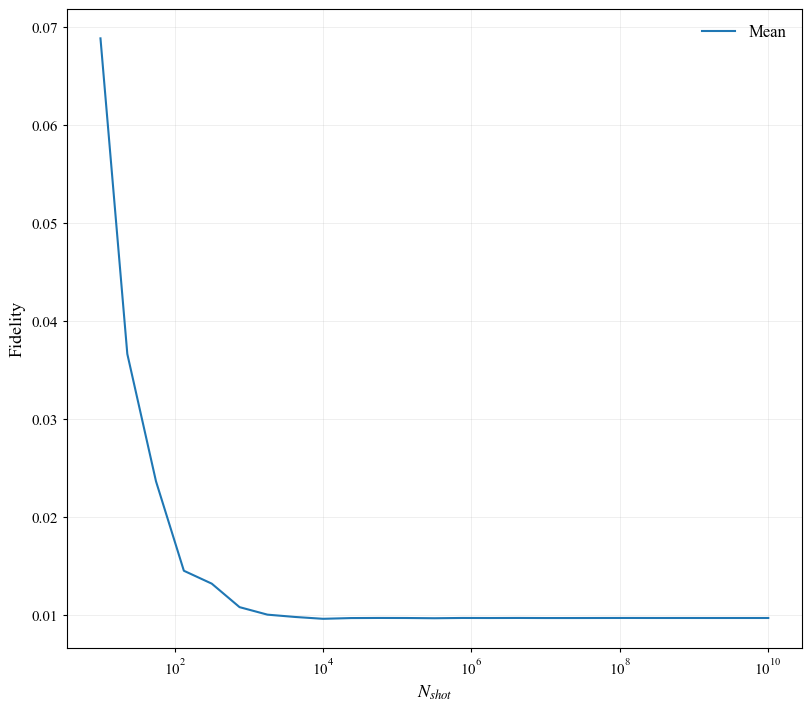

In [330]:
fig, ax = plt.subplots(ncols=1, dpi=100, figsize=(8,7))
ax.plot(shots, qst_fids)
ax.set_xlabel(r'$N_{shot}$')
ax.set_ylabel('Fidelity')
ax.legend(['Mean', r'$\sigma$'])
ax.set_xscale('log')

## QELM QST

In [331]:
def channel(gate):
    c_gate = copy.deepcopy(gate)
    def f(state):
        return c_gate @ state @ c_gate.hConj()
    return f

def rz_gate(theta):
    return Operator(np.array([[np.exp(-1j*theta/2),0],[0,np.exp(1j*theta/2)]]))

def ry_gate(theta):
    return Operator(np.array([[np.cos(theta/2),-np.sin(theta/2)],[np.sin(theta/2),np.cos(theta/2)]]))

def training_data_rotations(z_angles: np.ndarray, y_angles: np.ndarray, z_gates: dict, y_gates: dict):
    rotations = []

    for theta_y in y_angles:
        if theta_y == 0:
            rotations.append(lambda s: channel(I(8))(s))
        elif theta_y == np.pi:
            rotations.append(lambda s, ty = theta_y: y_gates[ty](s))
        else:
            for theta_z in z_angles:
                if theta_z == 0:
                    rotations.append(lambda s, ty = theta_y: channel(I(8))(y_gates[ty](s)))
                else:
                    rotations.append(lambda s, tz = theta_z, ty = theta_y: z_gates[tz](y_gates[ty](s)))
    
    return rotations


In [332]:
def training_data_rotations_from_angles(z_angles: np.ndarray, y_angles: np.ndarray, gate_noise = 0.063, lambda1 = 0):
    # Standard ideal gates
    z_gates = {z: (lambda s, tz=z: channel(rz_gate(tz)^I(4))(s)) for z in z_angles}
    y_gates = {y: (lambda s, ty=y: channel(ry_gate(ty)^I(4))(s)) for y in y_angles}
    
    dep = generateDepolarisingChannel((0,), lambda1)
    
    if noise_active:
        z_gates_noisy = {}
        for z in z_angles:
            # 1. Generate the noisy matrix ONCE for this angle
            static_noisy_z = generateNoisyGate(rz_gate(z), gate_noise)
            # 2. Bind it to the lambda via a default argument
            z_gates_noisy[z] = lambda s, g=static_noisy_z: dep(channel(g^I(4))(s))
            
        y_gates_noisy = {}
        for y in y_angles:
            static_noisy_y = generateNoisyGate(ry_gate(y), gate_noise)
            y_gates_noisy[y] = lambda s, g=static_noisy_y: dep(channel(g^I(4))(s))
    else:
        z_gates_noisy = z_gates
        y_gates_noisy = y_gates

    rotations = training_data_rotations(z_angles, y_angles, z_gates, y_gates)
    noisy_rotations = training_data_rotations(z_angles, y_angles, z_gates_noisy, y_gates_noisy)

    return rotations, noisy_rotations

In [333]:
training_data_sizes = [1,2]
training_states = []
training_rotations = []
training_rotations_noisy = []

for size in training_data_sizes:
    z_angles = np.linspace(0, 2*np.pi, 1 + 4*size)[:-1]
    y_angles = np.linspace(0, np.pi, 1 + 2*size)

    rotations, noisy_rotations = training_data_rotations_from_angles(z_angles, y_angles, rot_noise_1, lambda_dep_1)
    training_rotations.append(rotations)
    training_rotations_noisy.append(noisy_rotations)
    training_states.append([r(generateRegister()).partialTrace((2,2,2),(0,)) for r in rotations])

Visualise the training data on the Bloch sphere

In [334]:
states_bloch_noisy = [r(thermal_register_func()).partialTrace((2,2,2),(0,)) for r in training_rotations_noisy[0]]
blochs_noisy_thermal = [density_to_bloch(state) for state in states_bloch_noisy]

states_bloch_noisy = [r(noisy_register_func()).partialTrace((2,2,2),(0,))  for r in training_rotations_noisy[0]]
blochs_noisy_rot = [density_to_bloch(state) for state in states_bloch_noisy]

states_bloch = [r(generateRegister()).partialTrace((2,2,2),(0,))  for r in training_rotations_noisy[0]]
blochs = [density_to_bloch(state) for state in states_bloch]


/var/folders/8g/jdythvzn5njbj6km21j0m2080000gn/T/ipykernel_28491/3126987706.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


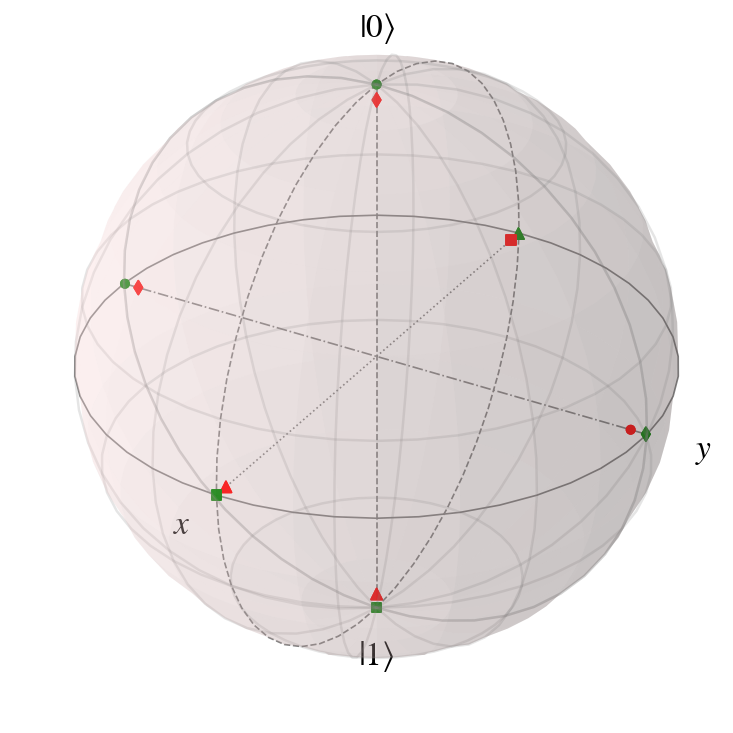

<Figure size 600x600 with 0 Axes>

In [335]:



# 3. Setup the Matplotlib figure for 3 side-by-side spheres
fig = plt.figure(figsize=(12, 6))


#ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# Initialize Bloch sphere on this specific axis
#for v in blochs:
##b = Bloch(axes=ax1)
#    b.add_points(list(v), colors=['g'])

#for v in blochs_noisy_rot:
#    b.add_points(list(v), colors='r')

#b.vector_width = 3

# We use render() instead of show() to keep them on the same figure
#b.render()
#ax1.set_title('Noisy Pure Register', fontsize=15, pad=20)

ax2 = fig.add_subplot(1, 1, 1, projection='3d')


b = Bloch(axes=ax2)
for v in blochs:
    b.add_points(list(v), colors=['g'])

for v in blochs_noisy_thermal:
    b.add_points(list(v), colors='r')

b.vector_width = 3

# We use render() instead of show() to keep them on the same figure
b.render()
#ax2.set_title("Thermal Register", fontsize=15, pad=20)

plt.tight_layout()
if save:

    fig.savefig("Plots/bloch_sphere_training_data.pdf")

In [336]:
import numpy as np

def optimize_readout_loocv(X, Y, lambdas):
    """
    Exact Leave-One-Out Cross Validation for optimal Tikhonov regularization.
    Immune to rank-deficiency traps and trace approximations.
    """
    n_samples = X.shape[0]
    loocv_scores = np.zeros(len(lambdas))
    
    for i, lam in enumerate(lambdas):
        error_sum = 0.0
        
        # Iterate through every single training state
        for j in range(n_samples):
            # 1. Create the training set by omitting state j
            X_train = np.delete(X, j, axis=0)
            Y_train = np.delete(Y, j, axis=0)
            
            # 2. Set aside state j for pure validation
            X_val = X[j:j+1]
            Y_val = Y[j:j+1]
            
            # 3. Fit the model on the remaining n-1 states
            U, s, Vh = np.linalg.svd(X_train, full_matrices=False)
            
            filter_factors = s / (s**2 + lam**2)
            U_dag_Y = U.conj().T @ Y_train
            
            if U_dag_Y.ndim == 1:
                filtered_Y = filter_factors * U_dag_Y
            else:
                filtered_Y = filter_factors[:, np.newaxis] * U_dag_Y
                
            W_lam = Vh.conj().T @ filtered_Y
            
            # 4. Predict the omitted state and calculate the exact error
            Y_pred = X_val @ W_lam
            
            # Use squared Frobenius norm for the error
            error_sum += np.linalg.norm(Y_pred - Y_val, ord='fro')**2
            
        # Average validation error across all n folds
        loocv_scores[i] = error_sum / n_samples
        
    # Pick the lambda that empirically predicted the held-out states best
    optimal_idx = np.argmin(loocv_scores)
    optimal_lambda = lambdas[optimal_idx]
    
    return optimal_lambda

In [337]:
from sklearn.linear_model import Ridge
def QELMTomography(reg_func, training_states, noisy_training_circuits, n_state_preps, circs, circ_shots, alpha=0):
    x_tr = []
    y_tr = []

    for state, noisy_circuit in (zip(training_states, noisy_training_circuits)):
        outcomes = collectMeasurementData(lambda: noisy_circuit(reg_func()), circs, np.max(n_state_preps))

        x_tr.append(outcomes)
        y_tr.append(density_to_bloch(state))

    regs = []

    for sh in n_state_preps:
        x_tr_reduced = np.array([[np.mean(row[0][:sh]), np.mean(row[1][:sh]), np.mean(row[2][:sh])] for row in x_tr])
        if alpha == 0:
            reg = LinearRegression()
            reg.fit(x_tr_reduced, y_tr, fit_intercept=True, r=4)
        else:
            reg = Ridge(alpha=alpha)
            reg.fit(x_tr_reduced, y_tr)
        regs.append(reg)
    return regs

def applyQELMTomography(reg_func, reg, n_state_preps, circs):
    
    r = np.mean(collectMeasurementData(reg_func, circs, n_state_preps), axis=1).reshape(1, -1)
    r = reg.predict(r)[0]
    if np.sum(r**2).real > 1:
        return r/np.sum(r**2).real
    else:
        return r

In [338]:
qelm_circs = (lambda shots: pauliCircuits(noisy_S, noisy_H, noisy_CNOT1, lambda1=lambda_dep_1, lambda2=lambda_dep_2, e0=e0, e1=e1, shots=shots))

In [339]:
def qelmStateTomographyInfidelity(regs, shots, reg_func, circs, Us, thermal=True):
    qelm_fids = []
    qelm_lower = []
    qelm_upper = []

    for i, shot in (enumerate((shots))):
        fid_trials = []
        for j in range(len(regs)):
            fid_U = []
            reg = regs[j][i]
            for U in Us:
                targ_f = lambda: U @ reg_func() @ U.hConj()
                if thermal:
                    est_state = bloch_to_density(applyQELMTomography(targ_f, reg, 1, circs(shot)))
                else:
                    est_state = bloch_to_density(applyQELMTomography(targ_f, reg, shot, circs(1)))
                #fid_U.append(1-fidelity(target, est_state))
                fid_U.append(1-fidelity(targ_f().partialTrace((2,2,2),(0,)), est_state))
            fid_trials.append(fid_U)
        qelm_fids.append(np.mean(fid_trials))
        qelm_lower.append(np.mean(np.percentile(fid_trials, 16, axis=0)))
        qelm_upper.append(np.mean(np.percentile(fid_trials, 84, axis=0)))

    return np.array(qelm_fids), np.array(qelm_lower), np.array(qelm_upper)

In [340]:
qelm_regs = []

for size in range(len(training_data_sizes)):
    qelm_regs.append([[QELMTomography(thermal_register_func, training_states[size], training_rotations_noisy[size], [1], qelm_circs(shot), shot, alpha=0)[0] for shot in shots] for trial in tqdm(range(trials))])

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [341]:
def plotQELMvsStandardInfidelity(reg_func, regs, shots, Us, training_states, qst_fids, qst_lowers, qst_uppers, circs, ax=None, legend=True):
    if ax is None:
        fig, ax = plt.subplots(ncols=1, dpi=100, figsize=(8,7))
    else:
        fig = None

    for size, reg_set in enumerate(regs):
        qelm_fids, qelm_lower, qelm_upper = qelmStateTomographyInfidelity(reg_set, shots, reg_func, circs, Us)
        
        ax.plot(shots, qelm_fids, label=f'QELM - {len(training_states[size])} states')
        ax.fill_between(
            shots, 
            qelm_lower, 
            qelm_upper, 
            alpha=0.15, 
        )

    # Standard QST perf
    fids = np.array(qst_fids)
    lowers = np.array(qst_lowers)
    uppers = np.array(qst_uppers)

    ax.plot(shots, fids, label='Standard QST')
    ax.fill_between(
            shots, 
            lowers, 
            uppers, 
            alpha=0.15, 
        )


    ax.set_xlabel(r'$N_{shot}$')
    ax.set_ylabel('Infidelity')
    if legend:
        ax.legend()
    ax.set_xscale('log')
    ax.set_yscale('log')
    return fig, ax

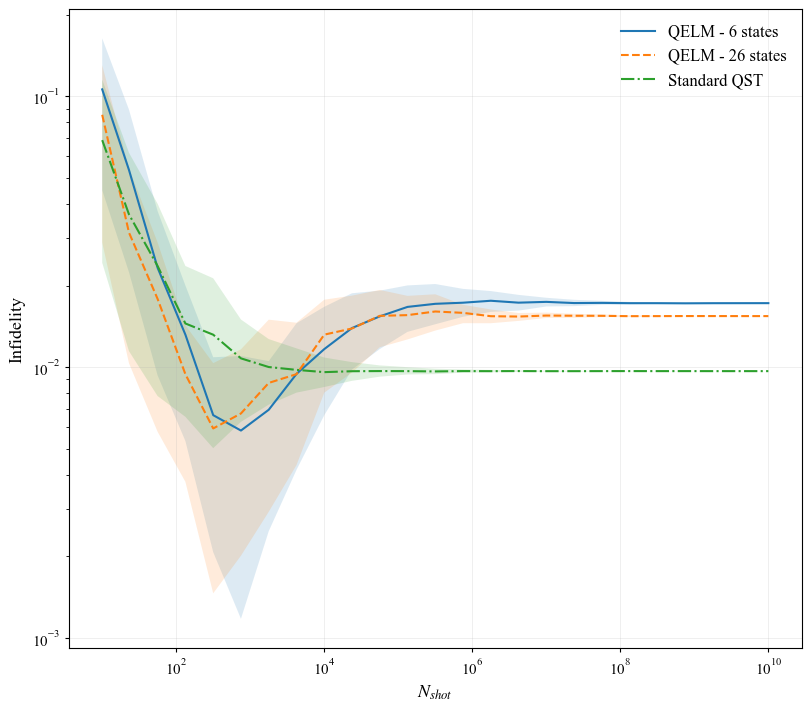

In [342]:
fig, ax = plotQELMvsStandardInfidelity(thermal_register_func, qelm_regs, shots, Us, training_states, qst_fids, qst_lowers, qst_uppers, qelm_circs)
if save:
    fig.savefig("Plots/qst_circuit_perf.pdf")

### 3.1 Noise Impact Analysis

In [343]:
shot_val = -1
e0s = np.linspace(0, 0.1, 10)
Ts = np.linspace(0.3, .8, 10)
lambda1s = np.linspace(0, 5* lambda_dep_1, 10)
lambda2s = np.linspace(0, 5 * lambda_dep_2, 10)

In [344]:
def reallyBadFunction(T, lambda1):
    training_data_sizes = [1]
    training_states = []
    training_rotations = []
    training_rotations_noisy = []

    for size in training_data_sizes:
        z_angles = np.linspace(0, 2*np.pi, 1 + 4*size)[:-1]
        y_angles = np.linspace(0, np.pi, 1 + 2*size)

        rotations, noisy_rotations = training_data_rotations_from_angles(z_angles, y_angles, rot_noise_1, lambda1)
        training_rotations.append(rotations)
        training_rotations_noisy.append(noisy_rotations)
        training_states.append([r(generateRegister()).partialTrace((2,2,2),(0,)) for r in rotations])
    return qelmStateTomographyInfidelity([QELMTomography(lambda:generateThermalRegister(T), training_states[0], training_rotations_noisy[0], [1], (lambda shots: pauliCircuits(noisy_S, noisy_H, noisy_CNOT1, lambda1=lambda1, lambda2=lambda1 * lambda_dep_2/lambda_dep_1, e0=e0, e1=e1, shots=shots))(shot_val), shot_val, alpha=0) for trial in range(1)], [shot_val], lambda:generateThermalRegister(T), (lambda shots: pauliCircuits(noisy_S, noisy_H, noisy_CNOT1, lambda1=lambda1, lambda2=lambda1 * lambda_dep_2/lambda_dep_1, e0=e0, e1=e1, shots=shots)), Us)[0][0] / quantumStateTomographyInfidelity([shot_val], lambda: generateThermalRegister(T), Us, lambda shot: pauliCircuits(noisy_S, noisy_H, noisy_CNOT1, lambda1, lambda1 * lambda_dep_2/lambda_dep_1, e0, e1, shots=shot))[0][0]

In [345]:

reallyBadFunction(0.56, lambda_dep_1)


np.float64(1.7818325476641477)

In [346]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# 1. Define the resolution of your sweep
# A 50x50 grid yields 2,500 simulation runs.
grid_resolution = 30

# Define the bounds for your two dominant parameters
# Update these ranges to match your specific physical bounds
# 1. Define the resolution of your sweep


# Use np.geomspace instead of np.logspace.
# You input the ACTUAL physical start and stop values.
# IMPORTANT: A logarithmic scale cannot start at exactly 0.0. 
# You must use a very small offset (e.g., 1e-5) for parameters that theoretically start at zero.

t_vals = np.geomspace(10**-1, 10**0, grid_resolution)           # e.g., 0.01 to 1.0         # Offset from 0 up to 0.1

# If exploring the depolarising channels:
dep_1_vals = np.geomspace(10e-2 * lambda_dep_1, 10**2 * lambda_dep_1, grid_resolution)     

# Create the 2D meshgrid
T_grid, RE_grid = np.meshgrid(t_vals, dep_1_vals)
#T_grid, RE_grid = np.meshgrid(dep_1_vals, dep_2_vals)

# 2. Lock the non-impactful parameters
# Setting the depolarising channels to standard fixed values

# Pre-allocate the Z array for the simulation output
Z_grid = np.zeros_like(T_grid)

# 3. Evaluate the model over the grid
print("Evaluating grid points...")
for i in tqdm(range(T_grid.shape[0])):
    for j in range(T_grid.shape[1]):
        
        # Construct the strict numpy array to prevent recompilation overhead
        # Order MUST match what your custom propagator expects
        params = np.array([
            T_grid[i, j], 
            RE_grid[i, j], 
        ], dtype=np.float64)

        #params = np.array([
        #    0.56, 
        #    0.01, 
        #    T_grid[i, j], 
        #    RE_grid[i, j],
        #], dtype=np.float64)
        
        # Replace with your actual simulation wrapper
        Z_grid[i, j] = reallyBadFunction(*params)

print("Evaluation complete. Generating plot...")



Evaluating grid points...


  0%|          | 0/30 [00:00<?, ?it/s]

KeyboardInterrupt: 

Evaluation complete. Generating fully logarithmic plot...


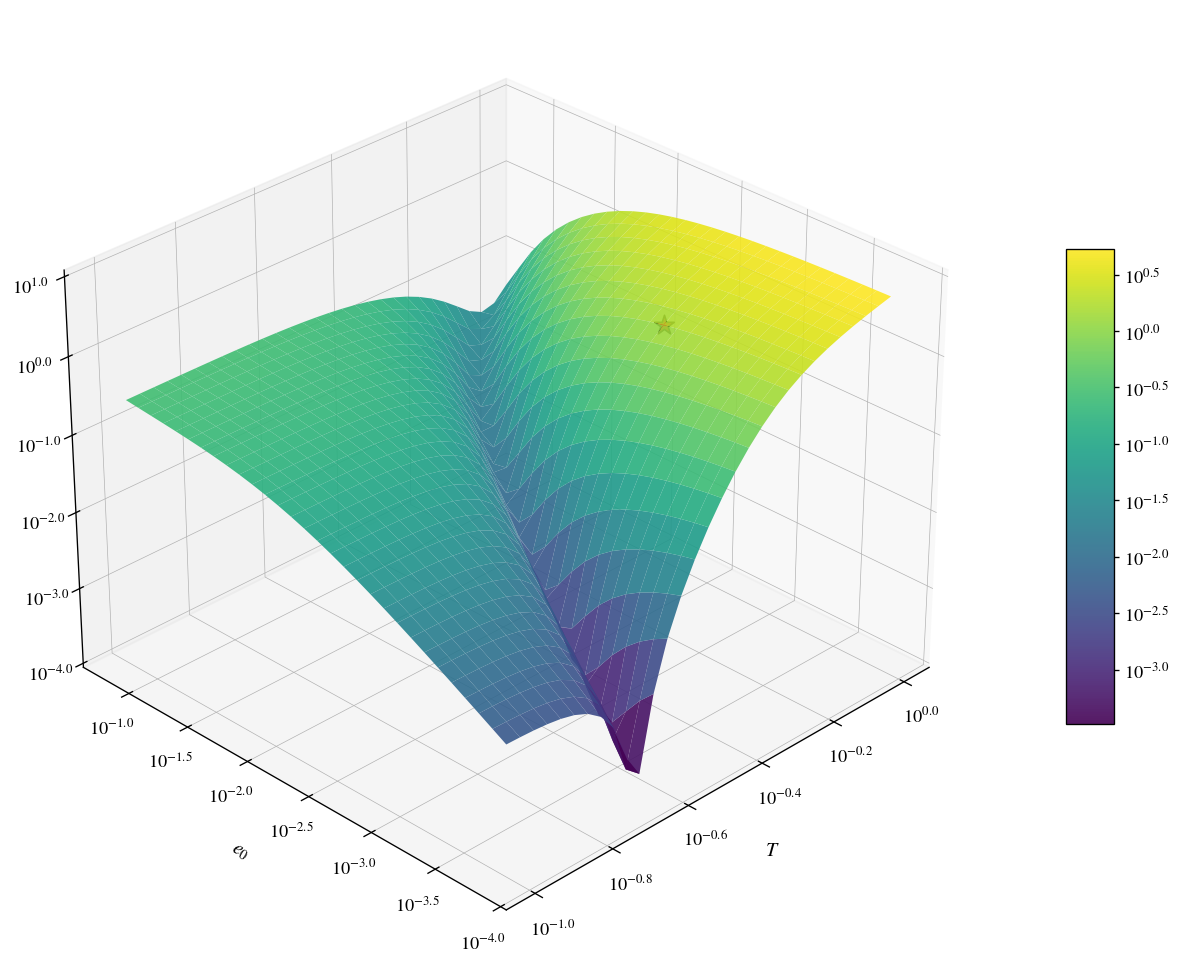

In [ ]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.ticker as ticker

# ... [Keep your previous grid generation and simulation code here] ...

print("Evaluation complete. Generating fully logarithmic plot...")

# 1. Manually take the log of X, Y, and Z data
# T_grid assumed to be > 0. RE_grid and Z_grid get an offset to prevent log(0) crashes.
# 1. Manually take the log of X, Y, and Z data
T_grid_log = np.log10(T_grid)
RE_grid_log = np.log10(RE_grid + 1e-15) 
Z_grid_log = np.log10(Z_grid + 1e-15)

# 2. Generate the Plot
fig = plt.figure(figsize=(10, 8), layout='constrained')
ax = fig.add_subplot(111, projection='3d')
# 2. Define the linear coordinates

# ... [Your existing log transformations] ...
T_grid_log = np.log10(T_grid)
RE_grid_log = np.log10(RE_grid + 1e-15) 
Z_grid_log = np.log10(Z_grid + 1e-15)

# 1. Define your target coordinates (in standard linear space)
x_val = 0.56
y_val = lambda_dep_1  # Ensure e0 is a single float number here, not an array

# 2. Calculate the distance from your target to every point on the grid
# We use the linear grids to find the closest physical parameter match
distances = (T_grid - x_val)**2 + (RE_grid - y_val)**2

# 3. Find the 2D index of the absolute closest point
closest_idx = np.unravel_index(np.argmin(distances), distances.shape)

# 4. Extract the exact log-space coordinates for that specific point
x_plot = T_grid_log[closest_idx]
y_plot = RE_grid_log[closest_idx]
z_plot = Z_grid_log[closest_idx]

# 5. Plot the marker
ax.scatter(
    x_plot, 
    y_plot, 
    z_plot, 
    color='red', 
    s=150, 
    marker='*', 
    edgecolors='black', 
    zorder=10,
    label='Target Point'
)

# ... [Now proceed to ax.plot_surface] ...
surf = ax.plot_surface(
    T_grid_log, 
    RE_grid_log, 
    Z_grid_log, 
    cmap=cm.viridis, 
    linewidth=0, 
    antialiased=True,
    alpha=0.9
)

# 3. Format ALL axis labels to show the true exponential values
def log_label_formatter(val, pos=None):
    return f"$10^{{{val:.1f}}}$"

log_formatter = ticker.FuncFormatter(log_label_formatter)

# Apply the formatter to X, Y, and Z axes
ax.xaxis.set_major_formatter(log_formatter)
ax.yaxis.set_major_formatter(log_formatter)
ax.zaxis.set_major_formatter(log_formatter)

# Labeling and aesthetics
ax.set_xlabel(r'$T$', labelpad=10, fontsize=12)
ax.set_ylabel(r'$e_0$', labelpad=10, fontsize=12)
ax.set_zlabel('Infidelity', labelpad=10, fontsize=12)

# Add the color bar and format its ticks to match
cbar = fig.colorbar(surf, shrink=0.5, aspect=10, pad=0.1)
cbar.ax.yaxis.set_major_formatter(log_formatter)

# Adjust the initial viewing angle
ax.view_init(elev=30, azim=225)

plt.show()

In [ ]:
Z_grid.shape

(20, 20)

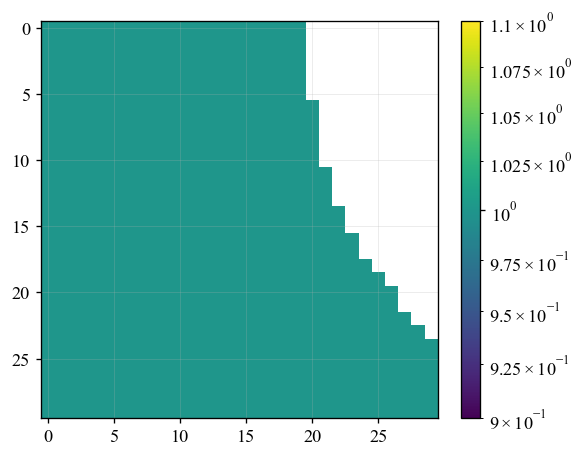

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Apply the LogNorm to the 'norm' parameter
plt.imshow(Z_grid<1, norm=colors.LogNorm())
# It is highly recommended to add a colorbar to see the new scale
plt.colorbar() 

plt.show()

### 3.1 Analysing infidelity as a funciton of regularisation

visualiseRegularisation(thermal_register_func, qelm_circs, training_states, training_rotations_noisy, Us, targets)

## 4. Detector Tomography Performance

In [ ]:
def QELMDetTomography(reg_func, training_states, noisy_training_circuits, n_state_preps, circs):
    x_tr = []
    y_tr = []

    for state, noisy_circuit in (zip(training_states, noisy_training_circuits)):
        outcomes = collectMeasurementData(lambda: noisy_circuit(reg_func()), circs, np.max(n_state_preps))

        x_tr.append(outcomes)
        y_tr.append(density_to_bloch(state))

    det_regs = []
    regs= []

    for shots in n_state_preps:
        reg = LinearRegression()
        x_tr_reduced = np.array([[np.mean(row[0][:shots]), np.mean(row[1][:shots]), np.mean(row[2][:shots])] for row in x_tr])
        reg.fit(x_tr_reduced, np.array(y_tr), fit_intercept=True, r=4)
        regs.append(reg)
        det_reg = LinearRegression()
        det_reg.fit(np.array(y_tr), x_tr_reduced, fit_intercept=True, r=4)
        det_regs.append(det_reg)

    return regs, det_regs


In [ ]:
def average_rmse_ob(reg, obs):
    qelm_ops = reg_to_op(reg)
    rmses = [rmse(op1, op2) for op1, op2 in zip(np.array(qelm_ops).T.flatten(), obs)]
    return np.mean(rmses)

In [ ]:
qelm_det_regs = []

for size in range(len(training_data_sizes)):
    qelm_det_regs.append([[QELMDetTomography(thermal_register_func, training_states[size], training_rotations_noisy[size], [1], qelm_circs(shot)) for shot in shots] for trial in tqdm(range(trials))])

  0%|          | 0/10 [00:00<?, ?it/s]

TypeError: QELMDetTomography() takes 5 positional arguments but 6 were given

In [ ]:
qelm_not_det_regs = np.array(qelm_det_regs)[:, :, :, 0, 0]
qelm_not_not_det_regs = np.array(qelm_det_regs)[:, :, :, 1, 0]

IndexError: too many indices for array: array is 1-dimensional, but 5 were indexed

In [ ]:
import numpy as np
import scipy.linalg

def reg_to_op(reg):
    """
    Extracts the effective detector operators from a trained regression model.
    
    Args:
        reg: Trained sklearn Ridge regression model predicting (X, Y, Z).
        paulis: Array of shape (3, 2, 2) containing [sigmaX, sigmaY, sigmaZ].
        identity: Array of shape (2, 2) containing the Identity matrix.
        
    Returns:
        operators: Array of shape (N, 2, 2) containing the extracted POVMs.
    """
    B = reg.coef_             # Shape: (3, N)
    b = reg.intercept_        # Shape: (3,)
    
    paulis = [sigmaX, sigmaY, sigmaZ]
    identity = I(2)

    # 1. Map from the 3 Paulis back to the N detectors
    B_inv = scipy.linalg.pinv(B)   # Shape: (N, 3)
    
    # 2. Calculate the identity weight vector: -B^+ b
    id_weights = -B_inv @ b        # Shape: (N,)
    
    # 3. Vectorized construction of all N operators
    # Multiply the (N, 3) weights by the (3, 2, 2) Paulis and sum over the Pauli axis
    pauli_terms = np.tensordot(B_inv, paulis, axes=([1], [0])) 
    
    # Scale the identity matrix by the identity weights for all N detectors
    identity_terms = np.tensordot(id_weights, identity, axes=0)
    
    return pauli_terms + identity_terms

# Example Usage:
# paulis = np.array([sigmaX, sigmaY, sigmaZ])
# povms = extract_detector_povms(reg_model, paulis, I(2))

/var/folders/8g/jdythvzn5njbj6km21j0m2080000gn/T/ipykernel_14174/182368239.py:100: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/matthewmackinnon/Documents/repos/QRes/.venv/lib/python3.12/site-packages/ipympl/backend_nbagg.py:392: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  self.figure.savefig(buf, format='png', dpi='figure')


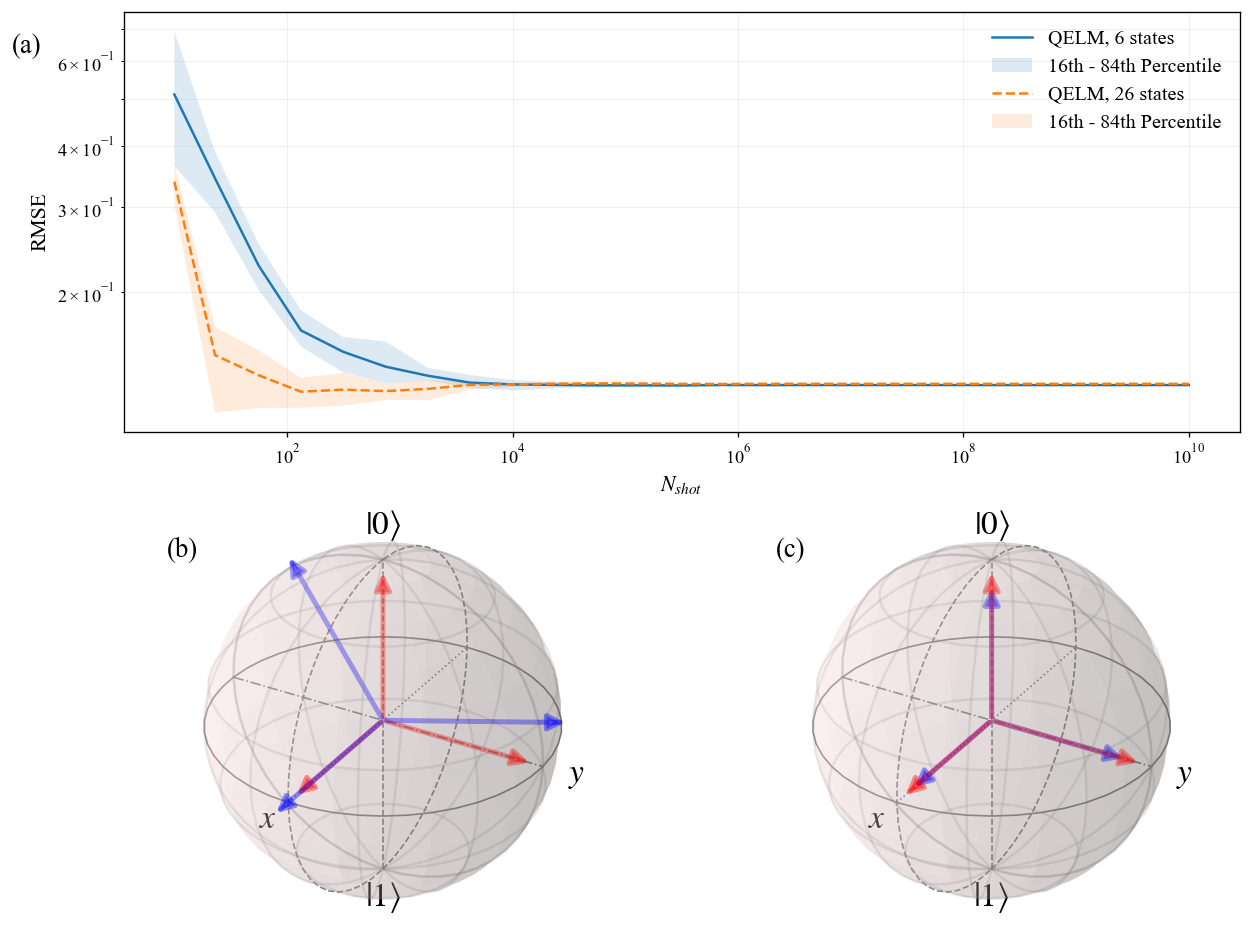

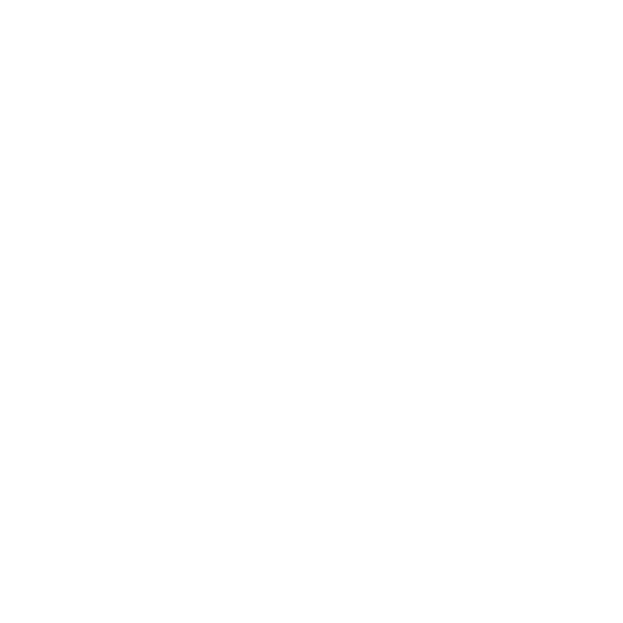

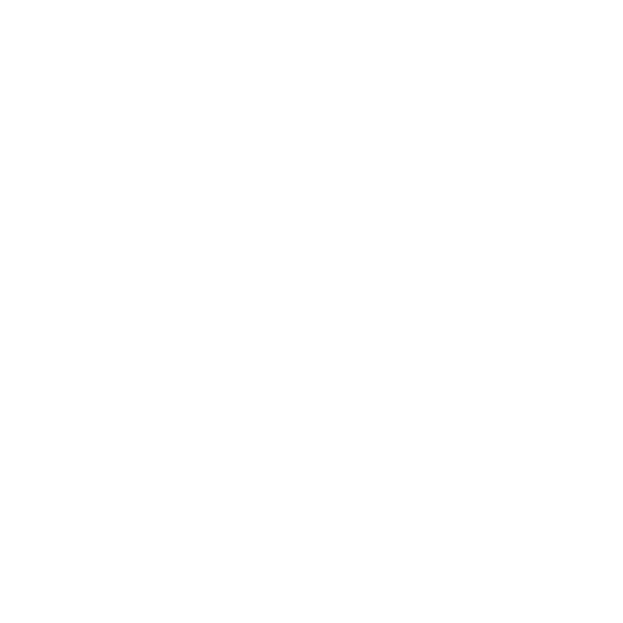

In [ ]:
def rmse(op1, op2):
    return (((op1 - op2).hConj() @ (op1 - op2)).trace()**0.5).real

def average_rmse(reg, povms, reg_func):
    qelm_ops = reg_to_op(reg)
    eff_ops = [[(op@(I(2)^Operator(reg_func().partialTrace((2,2,2),(1,2)).matrix))).partialTrace((2,2,2),(0,)) for op in povm] for povm in povms]
    return np.mean([rmse(op1, op2) for op1, op2 in zip(np.array(qelm_ops).T.flatten(), np.array(eff_ops).flatten())])



def det_reg_to_op(reg):
    return np.sum([[c * op for c, op in zip(row, [sigmaX, sigmaY, sigmaZ, I(2)])] for row in np.hstack([reg.coeff, reg.c.reshape(-1,1)])],axis=1)


these_regs = qelm_regs

obs =  [(op @ I(2).tensor(Operator(generateThermalRegister(0.56).partialTrace((2,2,2),(1,2)).matrix))).partialTrace((2,2,2),(0,)) for op in reversePauliOps(noisy_S, noisy_H, noisy_CNOT1, lambda_dep_1, lambda_dep_2)]
res = [[[average_rmse_ob(reg, obs) for reg in reg_trials] for reg_trials in reg_set] for reg_set in these_regs]
res_mean = np.mean(res, axis=1)
res_lower = np.percentile(res, 16, axis=1)
res_upper = np.percentile(res, 84, axis=1)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from qutip import Bloch, sigmax, sigmay, sigmaz
import numpy as np


ideal_ops = [op.matrix for op in obs]
idxs = [0,-1]

all_sets = [[
    op.matrix for op in reg_to_op(these_regs[0][0][i])  # Noisy Z
] for i in idxs]

labs = [shots[i] for i in idxs]
def operator_to_bloch_vector(op):
    op = np.array(op)
    rx = 0.5 * np.trace(op @ sigmax().full()).real
    ry = 0.5 * np.trace(op @ sigmay().full()).real
    rz = 0.5 * np.trace(op @ sigmaz().full()).real
    return [rx, ry, rz]

# 1. Setup the figure and GridSpec (2 rows, 2 columns)
fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1]) # Bottom row slightly taller for 3D

# 2. Top Line Plot: Spans row 0, both columns (0 and 1)
ax_top = fig.add_subplot(gs[0, :])

for i in range(len(these_regs)):
    rmses = res_mean[i]
    lowers = res_lower[i]
    uppers = res_upper[i]
    ax_top.plot(shots, rmses,label=f'QELM, {len(training_states[i])} states')
    plt.fill_between(
        shots, 
        lowers, 
        uppers, 
        alpha=0.15, 
        label=r'16th - 84th Percentile'
    )
ax_top.set_yscale('log')
ax_top.set_xscale('log')
ax_top.legend()
ax_top.set_xlabel(r'$N_{shot}$')
ax_top.set_ylabel(r'RMSE')
ax_top.grid(True, alpha=0.3, which='both', axis='y')
ax_top.grid(True, alpha=0.3, which='major', axis='x')
ax_top.annotate('(a)', xy=(-0.1, 0.95), xycoords='axes fraction', 
               fontsize=16, va='top')
# 3. Bottom Left: Bloch Sphere 1
ax_bl = fig.add_subplot(gs[1, 0], projection='3d')
b1 = Bloch(axes=ax_bl)
b1.vector_color = ['r', 'r', 'r', 'b', 'b', 'b']
b1.vector_alpha = [0.4, 0.4, .4, .4, .4, .4]
for op in ideal_ops:
    b1.add_vectors(operator_to_bloch_vector(op))
for op in all_sets[0]:
    b1.add_vectors(operator_to_bloch_vector(op))
b1.render()

# 4. Bottom Right: Bloch Sphere 2
ax_br = fig.add_subplot(gs[1, 1], projection='3d')
b2 = Bloch(axes=ax_br)
b2.vector_color = ['r', 'r', 'r', 'b', 'b', 'b']
b2.vector_alpha = [0.4, 0.4, .4, .4, .4, .4]
# Simulate a heavily depolarized result
for op in ideal_ops:
    b2.add_vectors(operator_to_bloch_vector(op))
for op in all_sets[1]:
    b2.add_vectors(operator_to_bloch_vector(op))
b2.render()

# Pass 0 for the 'z' argument, then use transAxes to override it
ax_bl.annotate('(b)', xy=(0, 0.95), xycoords='axes fraction', 
               fontsize=16, va='top')
ax_br.annotate('(c)', xy=(0, 0.95), xycoords='axes fraction', 
               fontsize=16, va='top')
plt.tight_layout()
if save:
    fig.savefig("Plots/detector_tomo_rmse.pdf")

## 5. QELM Tomography

In [ ]:
def twoQubitRandomGate(R1, R2, CR, lambda1, lambda2, depth = 1):
    dep11 = generateDepolarisingChannel((0,), lambda1)
    dep12 = generateDepolarisingChannel((1,), lambda1)
    dep2 = generateDepolarisingChannel((0,1,), lambda2)
    
    def f(state: DensityMatrix) -> DensityMatrix:
        return dep12(channel(I(2) ^R2^ I(2))(dep2(channel(CR ^ I(2))(dep11(channel(R1 ^ I(4))(state))))))

    def deep_f(state: DensityMatrix, k=depth) -> DensityMatrix:
        if k ==1:
            return f(state)
        else:
            return f(deep_f(state, k-1))
        
    return deep_f

In [ ]:
def twoQubitRandomPOVM(R1, R2, CR, lambda1, lambda2, e0, e1):
    povm1, povm2 = generateNoisyPOVM(e0, e1)
    dep11 = generateDepolarisingChannelHeisenberg((0,), lambda1)
    dep12 = generateDepolarisingChannelHeisenberg((1,), lambda1)
    dep2 = generateDepolarisingChannelHeisenberg((0,1,), lambda2)

    def f(op: Operator) -> Operator:
        return channel((R1 ^ I(2) ^ I(2)).hConj())(dep11(channel((CR ^ I(2)).hConj())(dep2(channel((I(2) ^ R2 ^ I(2)).hConj())(dep12(op))))))
    
    def deep_f(op: Operator, k) -> Operator:
        if k ==1:
            return f(op)
        else:
            return f(deep_f(op, k-1))
    return [[deep_f(I(2)^povm1^I(2), k=k), deep_f(I(2)^povm2^I(2), k=k)] for k in [1,2,3]]

def twoQubitRandomObservables(R1, R2, CR, lambda1, lambda2, e0, e1):
    povms = twoQubitRandomPOVM(R1, R2, CR, lambda1, lambda2, e0, e1)
    return [row[0] - row[1] for row in povms]

In [ ]:
def twoQubitRandomCircuit(R1, R2, CR, lambda1, lambda2, e0, e1, depth=1, shots=1):
    return setupDetectorDepolarising(twoQubitRandomGate(R1, R2, CR, lambda1, lambda2, depth), 1, e0, e1, shots)

In [ ]:
def randomTwoQubitCircuits(R1, R2, CR, lambda1, lambda2, e0, e1, shots=1):
    return [twoQubitRandomCircuit(R1, R2, CR, lambda1, lambda2, e0, e1, 1, shots), twoQubitRandomCircuit(R1, R2, CR, lambda1, lambda2, e0, e1, 2, shots), twoQubitRandomCircuit(R1, R2, CR, lambda1, lambda2, e0, e1, 3, shots)]

In [ ]:
R1 = Operator(haar_random_unitary(2))
R2 = Operator(haar_random_unitary(2))
U = Operator(haar_random_unitary(2))
CR = controlRotationGate(U)

In [ ]:
import numpy as np

def calculate_frame_potential(operators, normalize=True):
    """
    Calculates the 2nd-order frame potential for a set of quantum operators.
    
    Parameters:
    operators: A list or 3D numpy array of shape (N, d, d) containing the matrices.
    normalize: If True, divides by N^2 to allow comparison between different sized sets.
    """
    # Ensure operators are a 3D numpy array
    ops = np.asarray(operators)
    N = ops.shape[0]
    
    # Calculate the Hermitian conjugate of all operators
    ops_dagger = ops.conj().transpose(0, 2, 1)
    
    # We need to calculate Tr(M_j^\dagger @ M_k) for all j, k.
    # np.einsum is much faster than nested loops for this.
    # 'jab' is M_j^\dagger, 'kbc' is M_k. We sum over 'b' (matrix multiplication)
    # and then sum over 'a=c' (the trace operation).
    inner_products = np.einsum('jab, kba -> jk', ops_dagger, ops)
    
    # Square the absolute values of the traces and sum them all up
    F = np.sum(np.abs(inner_products)**2)
    
    if normalize:
        return F / (N**2)
    return F

In [ ]:
def reduceToEffectiveOps(reg_func, ops):
    return [(op @ I(2).tensor(Operator(reg_func().partialTrace((2,2,2),(1,2)).matrix))).partialTrace((2,2,2),(0,)).matrix for op in ops]

In [ ]:
random_regs = []

for size in range(len(training_data_sizes)):
    random_regs.append([[QELMTomography(thermal_register_func, training_states[size], training_rotations_noisy[size], [1], randomTwoQubitCircuits(R1, R2, CR, lambda_dep_1, lambda_dep_2, e0, e1, shot), alpha=0)[0] for shot in shots] for trial in tqdm(range(trials))])

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

random_regs, random_opt_alphas = optimiseRegularisationSingle(thermal_register_func, lambda shot: randomTwoQubitCircuits(R1, R2, CR, lambda_dep_1, lambda_dep_2, shot), training_states, training_rotations_noisy, val_Us, val_targets, shots, trials, bounds=(-5,-3))


visualiseRegularisation(thermal_register_func, lambda shot: randomTwoQubitCircuits(R1, R2, CR, lambda_dep_1, lambda_dep_2, shot), training_states, training_rotations_noisy, Us, targets)

(<Figure size 800x700 with 1 Axes>,
 <Axes: xlabel='$N_{shot}$', ylabel='Infidelity'>)

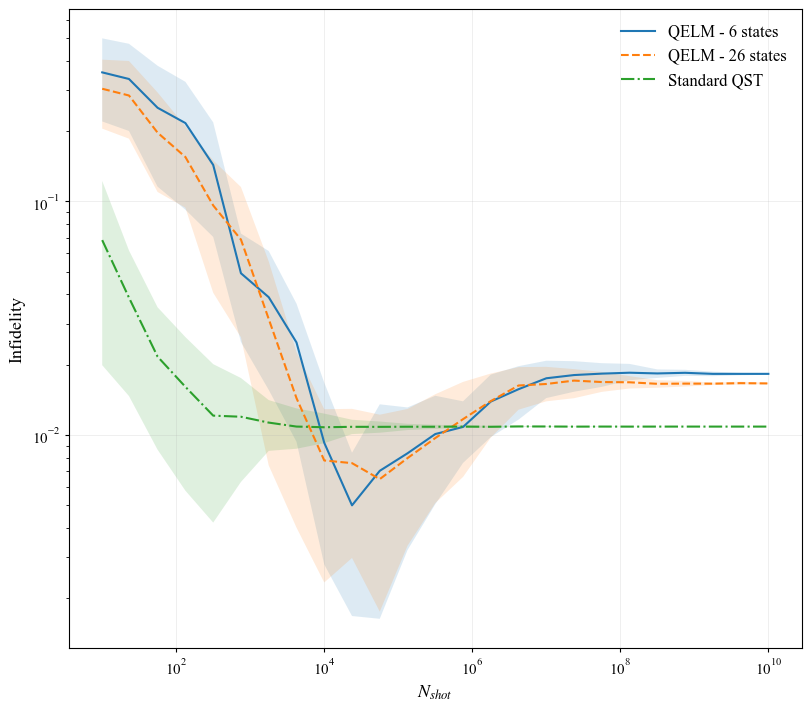

In [ ]:
plotQELMvsStandardInfidelity(thermal_register_func, random_regs, shots, Us[:5], training_states, qst_fids, qst_lowers, qst_uppers, lambda shots: randomTwoQubitCircuits(R1, R2, CR, lambda_dep_1, lambda_dep_2, e0, e1, shots))

### 5.1 QELM Tomography Performance Distribution

In [ ]:
n_dist_samples = 500
shot_powers = [1,3,4,5,6,8]
dist_shots = 10**np.array(shot_powers)
dist_shots = shots

In [ ]:
R1s = [Operator(haar_random_unitary(2)) for i in range(n_dist_samples)]
R2s = [Operator(haar_random_unitary(2)) for i in range(n_dist_samples)]
CRs = [controlRotationGate(Operator(haar_random_unitary(2))) for i in range(n_dist_samples)]

In [ ]:
random_regs_dist = [[QELMTomography(thermal_register_func, training_states[0], training_rotations_noisy[0], [1], randomTwoQubitCircuits(x, y, z, lambda_dep_1, lambda_dep_2, e0, e1, shot), alpha=0)[0] for shot in dist_shots] for x, y, z in tqdm(zip(R1s, R2s, CRs), total=len(R1s))]

  0%|          | 0/500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
perfs = np.array([qelmStateTomographyInfidelity([regs], dist_shots, thermal_register_func, lambda shots: randomTwoQubitCircuits(x, y, z, lambda_dep_1, lambda_dep_2, e0, e1, shots), Us, targets)[0] for x, y, z, regs in tqdm(zip(R1s, R2s, CRs, random_regs_dist), total=len(R1s))])

  0%|          | 0/500 [00:00<?, ?it/s]

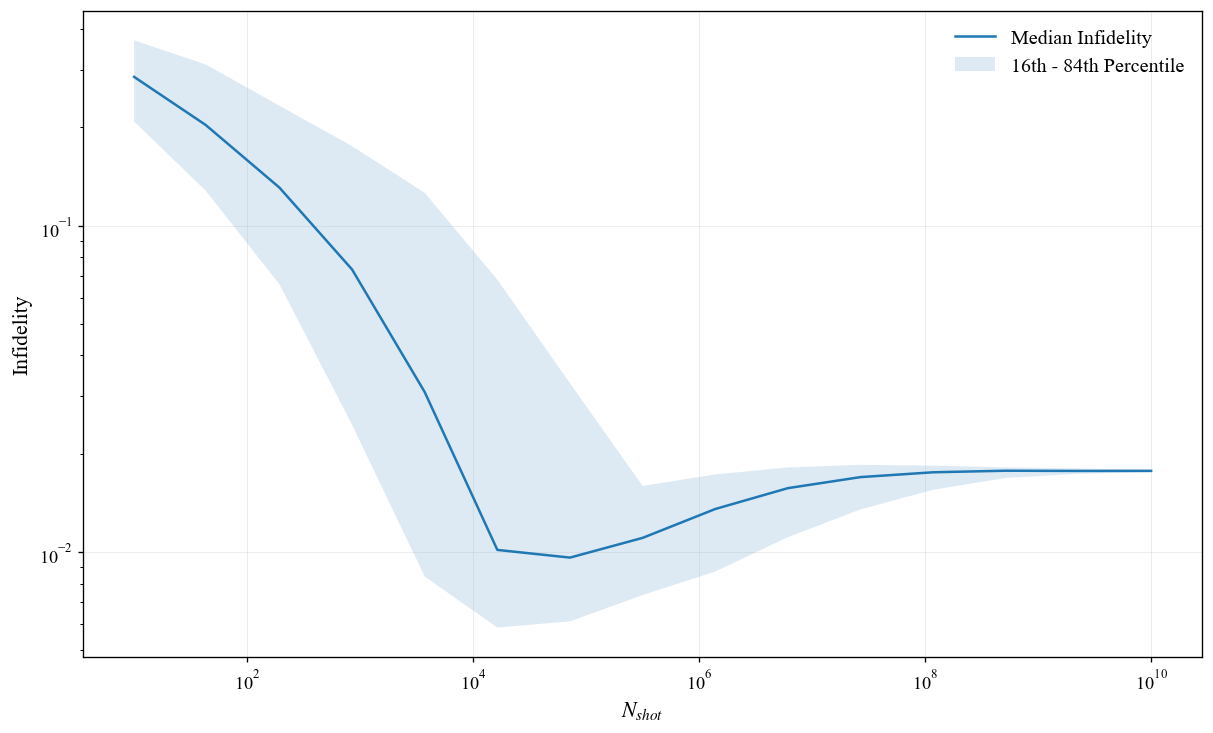

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Calculate the median instead of the mean for skewed data
medians = np.median(perfs, axis=0)

# Calculate the 16th and 84th percentiles (equivalent to +/- 1 standard dev)
lower_bound = np.percentile(perfs, 16, axis=0)
upper_bound = np.percentile(perfs, 84, axis=0)

# Plot the central line
plt.plot(sh, medians, label='Median Infidelity')

# Plot the shaded region using the percentiles
plt.fill_between(
    sh, 
    lower_bound, 
    upper_bound, 
    alpha=0.15, 
    label=r'16th - 84th Percentile'
)

plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$N_{shot}$')
plt.ylabel('Infidelity')
plt.legend()
plt.show()

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# If perfs is still a standard Python list from your list comprehension, 
# you MUST convert it to a NumPy array first for perfs[:, i] to work:
# perfs = np.array(perfs)

plt.figure(figsize=(10, 6))

for i in range(perfs.shape[1]):
    # Fetch the corresponding shot power for the label
    label_text = r'$N_{shots} = 10^' + str(shot_powers[i]) + r'$'
    
    sns.kdeplot(
        perfs[:, i], 
        log_scale=True,
        label=label_text, # Pass the custom label directly here
        fill=True, 
        alpha=0.4
    )

plt.title('Infidelity Probability Density')
plt.xlabel('Infidelity')
plt.ylabel('Density (Probability)')

# If you want to force a minimum x-limit on a log scale, 
# it MUST be a small positive number, not 0. For example:
# plt.xlim(left=1e-4) 

# Call legend without arguments, since the labels are already set in kdeplot
plt.legend() 
plt.show()

## 6. Wide QELM Tomography


In [ ]:
def threeQubitRandomCircuit(R1, R2, R3, CR1, CR2, lambda1, lambda2):
    dep11 = generateDepolarisingChannel((0,), lambda1)
    dep12 = generateDepolarisingChannel((1,), lambda1)
    dep13 = generateDepolarisingChannel((2,), lambda1)
    dep21 = generateDepolarisingChannel((0,1,), lambda2)
    dep22 = generateDepolarisingChannel((1,2,), lambda2)
    
    def f(state: DensityMatrix) -> DensityMatrix:
        return dep21(channel(CR1 ^ I(2))(dep11(dep12(dep13(channel(R1 ^ R2 ^ R3)(dep22(channel(I(2) ^ CR2)(dep21(channel(CR1 ^ I(2))(dep11(dep12(dep13(channel(R1 ^ R2 ^ R3)(state))))))))))))))
    return f

def randomThreeQubitCircuits(R1, R2, R3, CR1, CR2, lambda1, lambda2, shots=1):
    circ = threeQubitRandomCircuit(R1, R2, R3, CR1, CR2, lambda1, lambda2)
    return [setupDetectorDepolarising(circ, 1, shots), setupDetectorDepolarising(circ, 2, shots), setupJointDetectorDepolarising(circ, (1,2), shots)]

In [ ]:
def threeQubitRandomPOVM(R1, R2, R3, CR1, CR2, lambda1, lambda2):
    dep11 = generateDepolarisingChannelHeisenberg((0,), lambda1)
    dep12 = generateDepolarisingChannelHeisenberg((1,), lambda1)
    dep13 = generateDepolarisingChannelHeisenberg((2,), lambda1)
    dep21 = generateDepolarisingChannelHeisenberg((0,1,), lambda2)
    dep22 = generateDepolarisingChannelHeisenberg((1,2,), lambda2)

    def f(op: Operator) -> Operator:
        return channel((R1 ^ R2 ^ R3).hConj())(dep13(dep12(dep11(channel((CR1 ^ I(2).hConj()))(dep21(channel((I(2) ^ CR2).hConj())(dep22(channel((R1 ^ R2 ^ R3).hConj())(dep13(dep12(dep11(channel((CR1 ^ I(2)).hConj())(dep21(op))))))))))))))
    
    return [[f(I(2)^povm1^I(2)),f(I(2)^povm2^I(2))], [f(I(4)^povm1), f(I(4)^povm2)], [f(I(2)^povm1^povm1) + f(I(2)^povm2^povm2), f(I(2)^povm2^povm1) + f(I(2)^povm1^povm2)]]


def threeQubitRandomObservables(R1, R2, R3, CR1, CR2, lambda1, lambda2):
    povms = threeQubitRandomPOVM(R1, R2, R3, CR1, CR2, lambda1, lambda2)
    return [row[0] - row[1] for row in povms]

In [ ]:
R1_ = Operator(haar_random_unitary(2))
R2_ = Operator(haar_random_unitary(2))
R3_ = Operator(haar_random_unitary(2))
U1 = Operator(haar_random_unitary(2))
CR1 = controlRotationGate(U1)
U2 = Operator(haar_random_unitary(2))
CR2 = controlRotationGate(U2)

In [ ]:
wide_regs = []

for size in range(len(training_data_sizes)):
    wide_regs.append([[QELMTomography(thermal_register_func, training_states[size], training_rotations_noisy[size], [1], randomThreeQubitCircuits(R1_, R2_, R3_, CR1, CR2, lambda_dep_1, lambda_dep_2, shot))[0] for shot in sh] for trial in tqdm(range(trials))])

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

wide_regs, wide_opt_alphas = optimiseRegularisation(thermal_register_func, lambda shot: randomThreeQubitCircuits(R1_, R2_, R3_, CR1, CR2, lambda_dep_1, lambda_dep_2, shot), training_states, training_rotations_noisy, val_Us, val_targets, shots, trials, bounds=(-8,-1))

visualiseRegularisation(thermal_register_func, lambda shot: randomThreeQubitCircuits(R1_, R2_, R3_, CR1, CR2, lambda_dep_1, lambda_dep_2, shot), training_states, training_rotations_noisy, val_Us, val_targets)

(<Figure size 800x700 with 1 Axes>,
 <Axes: xlabel='$N_{shot}$', ylabel='Infidelity'>)

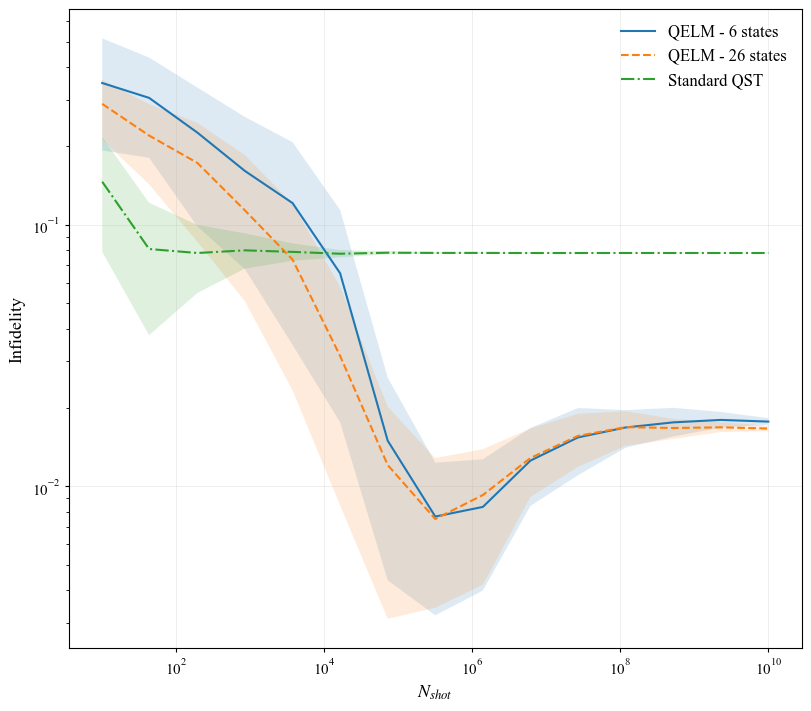

In [ ]:
plotQELMvsStandardInfidelity(thermal_register_func, wide_regs, sh, Us, targets, training_states, qst_fids, qst_vars, lambda shots: randomThreeQubitCircuits(R1_, R2_, R3_, CR1, CR2, lambda_dep_1, lambda_dep_2, shots))

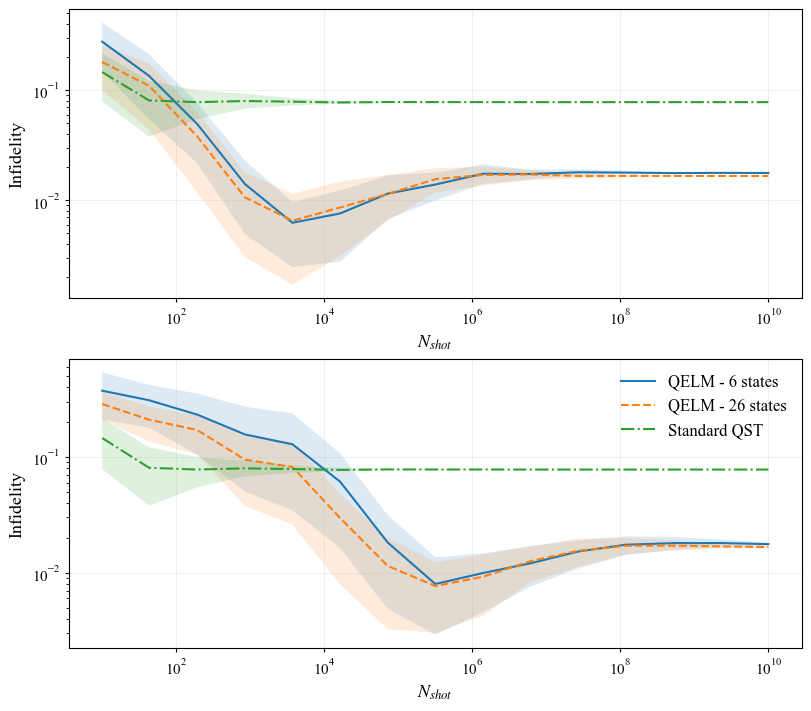

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=2, dpi=100, figsize=(8,7))
plotQELMvsStandardInfidelity(thermal_register_func, random_regs, sh, Us, targets, training_states, qst_fids, qst_vars, lambda shots: randomTwoQubitCircuits(R1, R2, CR, lambda_dep_1, lambda_dep_2, shots), ax = ax1, legend=False)
plotQELMvsStandardInfidelity(thermal_register_func, wide_regs, sh, Us, targets, training_states, qst_fids, qst_vars, lambda shots: randomThreeQubitCircuits(R1_, R2_, R3_, CR1, CR2, lambda_dep_1, lambda_dep_2, shots), ax=ax2)

if save:
    fig.savefig("Plots/random_tomo_perf.pdf")

### 6.1 Wide QELM Distribution

In [ ]:
R1s_ = [Operator(haar_random_unitary(2)) for i in range(n_dist_samples)]
R2s_ = [Operator(haar_random_unitary(2)) for i in range(n_dist_samples)]
R3s_ = [Operator(haar_random_unitary(2)) for i in range(n_dist_samples)]
CR1s_ = [controlRotationGate(Operator(haar_random_unitary(2))) for i in range(n_dist_samples)]
CR2s_ = [controlRotationGate(Operator(haar_random_unitary(2))) for i in range(n_dist_samples)]

In [ ]:
random_wide_regs_dist = [[QELMTomography(thermal_register_func, training_states[0], training_rotations_noisy[0], [1], randomThreeQubitCircuits(x, y, z, a, b, lambda_dep_1, lambda_dep_2, shot), alpha=0)[0] for shot in dist_shots] for x, y, z, a, b in tqdm(zip(R1s_, R2s_, R3s_, CR1s_, CR2s_), total=len(R1s))]

  0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
perfs_wide = np.array([qelmStateTomographyInfidelity([regs], dist_shots, thermal_register_func, lambda shots: randomThreeQubitCircuits(x, y, z, a, b, lambda_dep_1, lambda_dep_2, shots), Us, targets)[0] for x, y, z, a, b, regs in tqdm(zip(R1s_, R2s_, R3s_, CR1s_, CR2s_, random_wide_regs_dist), total=len(R1s))])

  0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
direct_perfs = np.array([[qelmStateTomographyInfidelity([regs], sh, thermal_register_func, qelm_circs, Us, targets)][0][0] for regs in qelm_regs[0]])

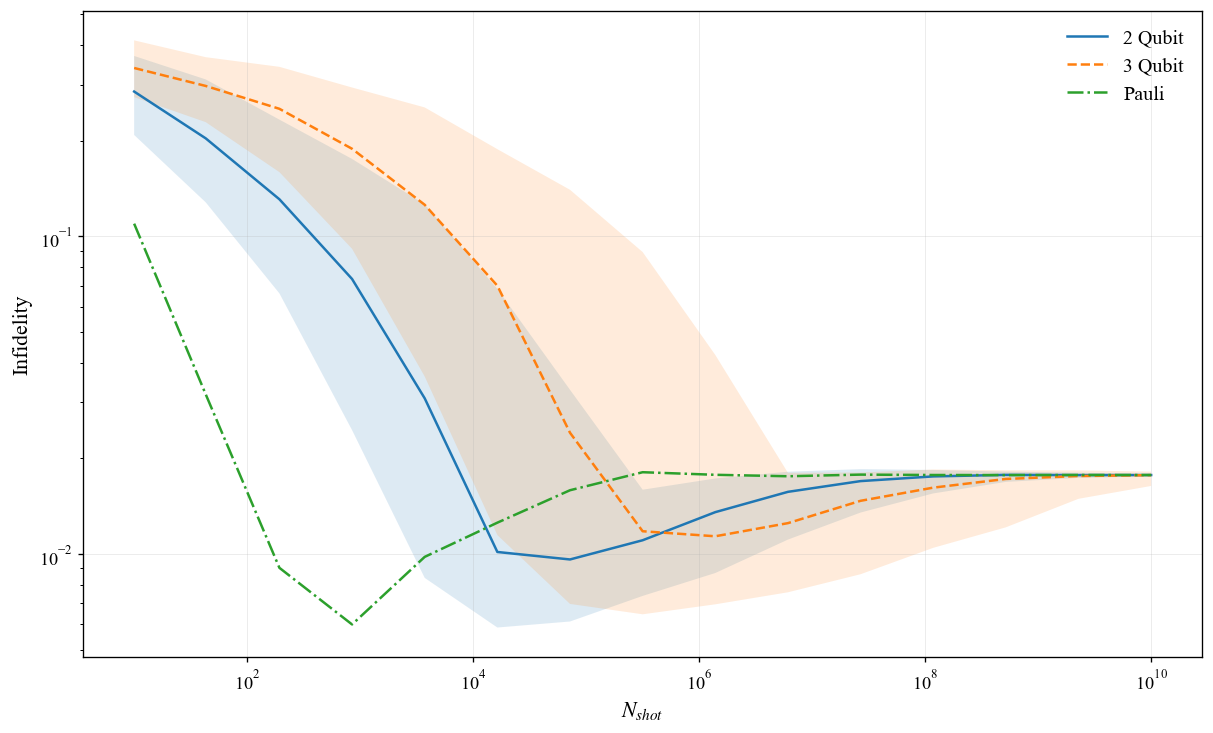

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Calculate the median instead of the mean for skewed data
medians = np.median(perfs, axis=0)
medians_wide = np.median(perfs_wide, axis=0)

# Calculate the 16th and 84th percentiles (equivalent to +/- 1 standard dev)
lower_bound = np.percentile(perfs, 16, axis=0)
upper_bound = np.percentile(perfs, 84, axis=0)
lower_bound_wide = np.percentile(perfs_wide, 16, axis=0)
upper_bound_wide = np.percentile(perfs_wide, 84, axis=0)

# Plot the central line

plt.plot(sh, medians, label='2 Qubit')
plt.plot(sh, medians_wide, label='3 Qubit')
plt.plot(sh, np.mean(direct_perfs, axis=0), label = 'Pauli')

# Plot the shaded region using the percentiles
plt.fill_between(
    sh, 
    lower_bound, 
    upper_bound, 
    alpha=0.15, 
)

plt.fill_between(
    sh, 
    lower_bound_wide, 
    upper_bound_wide, 
    alpha=0.15, 
)

plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$N_{shot}$')
plt.ylabel('Infidelity')
plt.legend()
plt.show()

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# If perfs is still a standard Python list from your list comprehension, 
# you MUST convert it to a NumPy array first for perfs[:, i] to work:
# perfs = np.array(perfs)

plt.figure(figsize=(10, 6))

for i in range(perfs_wide.shape[1]):
    # Fetch the corresponding shot power for the label
    label_text = r'$N_{shots} = 10^' + str(shot_powers[i]) + r'$'
    
    sns.kdeplot(
        perfs_wide[:, i], 
        log_scale=True,
        label=label_text, # Pass the custom label directly here
        fill=True, 
        alpha=0.4
    )

plt.title('Infidelity Probability Density')
plt.xlabel('Infidelity')
plt.ylabel('Density (Probability)')

# If you want to force a minimum x-limit on a log scale, 
# it MUST be a small positive number, not 0. For example:
# plt.xlim(left=1e-4) 

# Call legend without arguments, since the labels are already set in kdeplot
plt.legend() 
plt.show()

In [ ]:
calculate_average_hs_distance([0.5*np.array([[1,1],[1,1]]), 0.5*np.array([[1,-1],[-1,1]]),0.5*np.array([[1,-1j],[1j,1]]), 0.5*np.array([[1,1j],[-1j,1]]),np.array([[1,0],[0,0]]), np.array([[0,0],[0,1]])])

np.float64(1.082842712474619)

In [ ]:
calculate_average_hs_distance(reduceToEffectiveOps(thermal_register_func, np.array(reversePauliPOVM(noisy_S, noisy_H, noisy_CNOT1, lambda_dep_1, lambda_dep_2)).flatten()))

np.float64(0.9753085340091885)

In [ ]:
calculate_average_hs_distance(reduceToEffectiveOps(thermal_register_func, np.array(twoQubitRandomPOVM(R1, R2, CR, lambda_dep_1, lambda_dep_2)).flatten()))

np.float64(0.6092196611403923)

In [ ]:
calculate_average_hs_distance(reduceToEffectiveOps(thermal_register_func, np.array(threeQubitRandomPOVM(R1_, R2_, R3_, CR1, CR2, lambda_dep_1, lambda_dep_2)).flatten()))

np.float64(0.4795520411191386)

/var/folders/8g/jdythvzn5njbj6km21j0m2080000gn/T/ipykernel_5801/3668713933.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


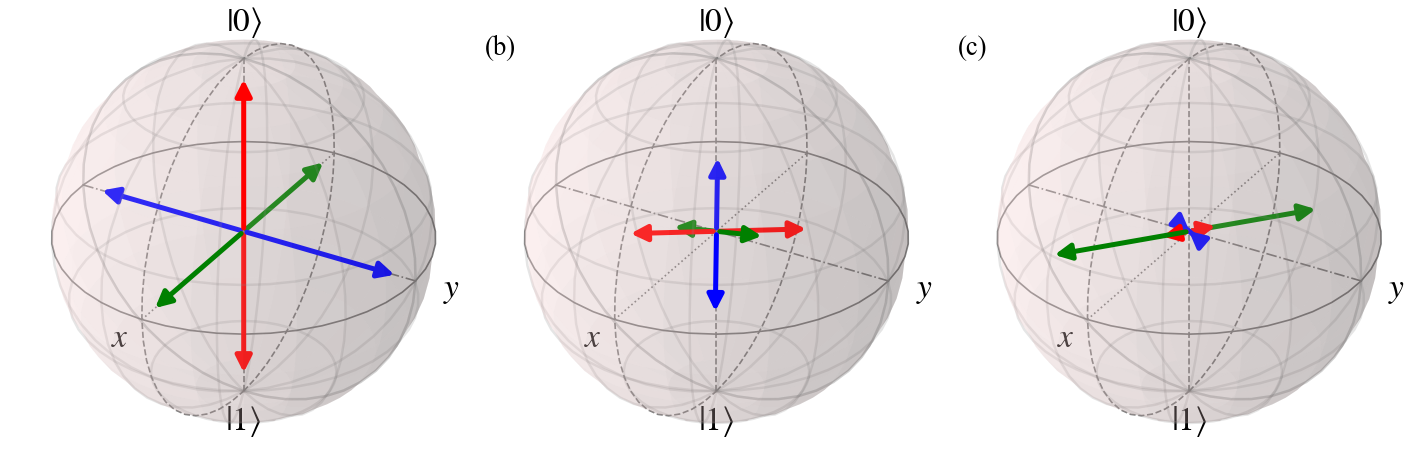

In [ ]:


labs = [sh[i] for i in idxs]
def operator_to_bloch_vector(op):
    op = np.array(op)
    rx = np.trace(op @ sigmax().full()).real
    ry = np.trace(op @ sigmay().full()).real
    rz = np.trace(op @ sigmaz().full()).real
    return [rx, ry, rz]

# 1. Setup the figure and GridSpec (2 rows, 2 columns)
fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(1, 3) # Bottom row slightly taller for 3D

ax_bx = fig.add_subplot(gs[0, 0], projection='3d')
b1 = Bloch(axes=ax_bx)
b1.vector_color = ['g','g','b','b','r','r']
for op in reduceToEffectiveOps(thermal_register_func, np.array(reversePauliPOVM(noisy_S, noisy_H, noisy_CNOT1, lambda_dep_1, lambda_dep_2)).flatten()):
    b1.add_vectors(operator_to_bloch_vector(op))
b1.render()

# 3. Bottom Left: Bloch Sphere 1
ax_bl = fig.add_subplot(gs[0, 1], projection='3d')
b2 = Bloch(axes=ax_bl)
b2.vector_color = ['g','g','b','b','r','r']
for op in reduceToEffectiveOps(thermal_register_func, np.array(twoQubitRandomPOVM(R1, R2, CR, lambda_dep_1, lambda_dep_2)).flatten()):
    b2.add_vectors(operator_to_bloch_vector(op))
b2.render()

# 4. Bottom Right: Bloch Sphere 2
ax_br = fig.add_subplot(gs[0, 2], projection='3d')
b3 = Bloch(axes=ax_br)
b3.vector_color = ['g','g','b','b','r','r']
# Simulate a heavily depolarized result
for op in reduceToEffectiveOps(thermal_register_func, np.array(threeQubitRandomPOVM(R1_, R2_, R3_, CR1, CR2, lambda_dep_1, lambda_dep_2)).flatten()):
    b3.add_vectors(operator_to_bloch_vector(op))
b3.render()

# Pass 0 for the 'z' argument, then use transAxes to override it
ax_bl.annotate('(b)', xy=(0, 0.95), xycoords='axes fraction', 
               fontsize=16, va='top')
ax_br.annotate('(c)', xy=(0, 0.95), xycoords='axes fraction', 
               fontsize=16, va='top')
plt.tight_layout()
if save:
    fig.savefig("Plots/detector_tomo_rmse.pdf")


/var/folders/8g/jdythvzn5njbj6km21j0m2080000gn/T/ipykernel_5801/1694412700.py:46: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


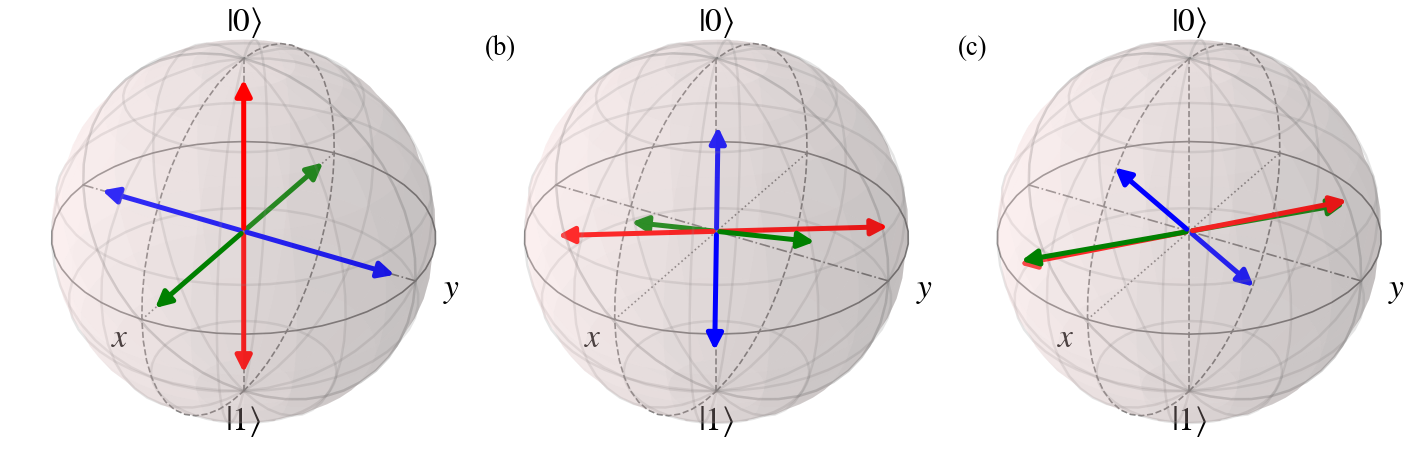

In [ ]:


labs = [sh[i] for i in idxs]
def operator_to_bloch_vector(op):
    op = np.array(op)
    rx = np.trace(op @ sigmax().full()).real
    ry = np.trace(op @ sigmay().full()).real
    rz = np.trace(op @ sigmaz().full()).real
    return np.array([rx, ry, rz])

# 1. Setup the figure and GridSpec (2 rows, 2 columns)
fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(1, 3) # Bottom row slightly taller for 3D

ax_bx = fig.add_subplot(gs[0, 0], projection='3d')
b1 = Bloch(axes=ax_bx)
b1.vector_color = ['g','g','b','b','r','r']
for op in reduceToEffectiveOps(thermal_register_func, np.array(reversePauliPOVM(noisy_S, noisy_H, noisy_CNOT1, lambda_dep_1, lambda_dep_2)).flatten()):
    b1.add_vectors(operator_to_bloch_vector(op))
b1.render()

# 3. Bottom Left: Bloch Sphere 1
ax_bl = fig.add_subplot(gs[0, 1], projection='3d')
b2 = Bloch(axes=ax_bl)
b2.vector_color = ['g','g','b','b','r','r']
for op in reduceToEffectiveOps(thermal_register_func, np.array(twoQubitRandomPOVM(R1, R2, CR, lambda_dep_1, lambda_dep_2)).flatten()):
    v = operator_to_bloch_vector(op)
    v = v/np.sum(v**2)**0.5
    b2.add_vectors(v)
b2.render()

# 4. Bottom Right: Bloch Sphere 2
ax_br = fig.add_subplot(gs[0, 2], projection='3d')
b3 = Bloch(axes=ax_br)
b3.vector_color = ['g','g','b','b','r','r']
# Simulate a heavily depolarized result
for op in reduceToEffectiveOps(thermal_register_func, np.array(threeQubitRandomPOVM(R1_, R2_, R3_, CR1, CR2, lambda_dep_1, lambda_dep_2)).flatten()):
    v = operator_to_bloch_vector(op)
    v = v/np.sum(v**2)**0.5
    b3.add_vectors(v)
b3.render()

# Pass 0 for the 'z' argument, then use transAxes to override it
ax_bl.annotate('(b)', xy=(0, 0.95), xycoords='axes fraction', 
               fontsize=16, va='top')
ax_br.annotate('(c)', xy=(0, 0.95), xycoords='axes fraction', 
               fontsize=16, va='top')
plt.tight_layout()
if save:
    fig.savefig("Plots/detector_tomo_rmse.pdf")


## 7. Comparison of thermal register vs random pure register

temp_shots = (10**np.linspace(0,4,10)).astype(int)

qst_fids_thermal, qst_vars_thermal = quantumStateTomographyInfidelity(temp_shots, thermal_register_func, Us[::10], targets[::10], lambda shot: pauliCircuits(noisy_S, noisy_H, noisy_CNOT1, shot))
qst_fids_pure, qst_vars_pure = quantumStateTomographyInfidelity(temp_shots, noisy_register_func, Us[::10], targets[::10], lambda shot: pauliCircuits(noisy_S, noisy_H, noisy_CNOT1, shot), thermal=False)

reduced_trials = 5

thermal_regs = [[QELMTomography(thermal_register_func, training_states[0], training_rotations_noisy[0], [1], qelm_circs(shot))[0] for shot in temp_shots] for trial in tqdm(range(reduced_trials))]
pure_regs = [QELMTomography(noisy_register_func, training_states[0], training_rotations_noisy[0], temp_shots, qelm_circs(1)) for trial in tqdm(range(reduced_trials))]

qelm_fids_thermal, qelm_vars_thermal = qelmStateTomographyInfidelity(thermal_regs, temp_shots, thermal_register_func, qelm_circs, Us[::10], targets[::10])
qelm_fids_pure, qelm_vars_pure = qelmStateTomographyInfidelity(pure_regs, temp_shots, noisy_register_func, qelm_circs, Us[::10], targets[::10], thermal=False)


fig, ax = plt.subplots(ncols=1, dpi=100, figsize=(8,7))

ax.plot(temp_shots, qelm_fids_thermal, label=f'QELM, Thermal Register')
ax.fill_between(temp_shots, (np.array(qelm_fids_thermal) - np.array(qelm_vars_thermal)), (np.array(qelm_fids_thermal) + np.array(qelm_vars_thermal)), alpha=0.1)
ax.plot(temp_shots, qelm_fids_pure, label=f'QELM, Noisy Pure Register')
ax.fill_between(temp_shots, (np.array(qelm_fids_pure) - np.array(qelm_vars_pure)), (np.array(qelm_fids_pure) + np.array(qelm_vars_pure)), alpha=0.1)

ax.plot(temp_shots, qst_fids_thermal, label=f'QST, Thermal Register')
ax.fill_between(temp_shots, (np.array(qst_fids_thermal) - np.array(qst_vars_thermal)), (np.array(qst_fids_thermal) + np.array(qst_vars_thermal)), alpha=0.1)
ax.plot(temp_shots, qst_fids_pure, label=f'QST, Noisy Pure Register')
ax.fill_between(temp_shots, (np.array(qst_fids_pure) - np.array(qst_vars_pure)), (np.array(qst_fids_pure) + np.array(qst_vars_pure)), alpha=0.1)

ax.set_xlabel(r'$N_{shot}$')
ax.set_ylabel('Infidelity')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
if save:
    fig.savefig("Plots/register_perf_comparison.pdf")

## 8. Comparison of Train vs Test shots

In [ ]:
regs = []

for size in range(len(training_data_sizes)):
    regs.append([[QELMTomography(thermal_register_func, training_states_dep[size], training_rotations_noisy_dep[size], [1], randomTwoQubitCircuits(R1, R2, CR, lambda_dep_1, lambda_dep_2, shot))[0] for shot in sh] for trial in tqdm(range(trials))])

res = [qelmStateTomographyInfidelity(regs[0], [shot for i in range(len(sh))], thermal_register_func, lambda shot: randomTwoQubitCircuits(R1, R2, CR, lambda_dep_1, lambda_dep_2, shot), Us, targets) for shot in sh]

  0%|          | 0/10 [00:00<?, ?it/s]

NameError: name 'training_states_dep' is not defined

In [ ]:
regs, pt_alphas = optimiseRegularisation(thermal_register_func, lambda shot: randomTwoQubitCircuits(R1, R2, CR, lambda_dep_1, lambda_dep_2, shot), training_states, training_rotations_noisy, val_Us, val_targets, sh, trials)
res = [qelmStateTomographyInfidelity(regs[0], [shot for i in range(len(sh))], thermal_register_func, lambda shot: randomTwoQubitCircuits(R1, R2, CR, lambda_dep_1, lambda_dep_2, shot), Us, targets) for shot in sh]

[np.float64(0.0005523376453011941), np.float64(0.0018840990051499978)]


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

regs = []

for size in range(len(training_data_sizes)):
    regs.append([[QELMTomography(thermal_register_func, training_states[size], training_rotations_noisy[size], [1], randomThreeQubitCircuits(R1_, R2_, R3_, CR1, CR2, shot))[0] for shot in shots] for trial in tqdm(range(trials))])

res = [qelmStateTomographyInfidelity(regs[0], [shot for i in range(len(shots))], thermal_register_func, lambda shot: randomThreeQubitCircuits(R1_, R2_, R3_, CR1, CR2, shot), Us, targets) for shot in shots]

In [ ]:
np.array(res).shape

(15, 2, 15)

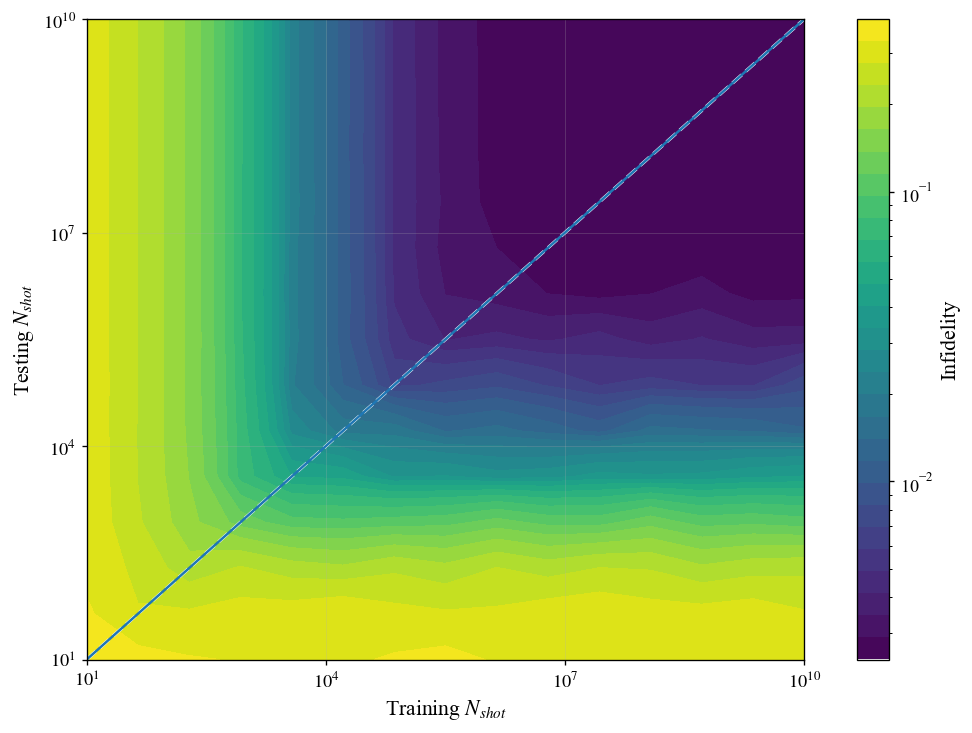

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.colors import LogNorm
labs = list(sh[::5]) + [sh[-1]]
# 1. Create a grid of data
x = np.linspace(0, len(labs)-1, len(sh))
y = np.linspace(0, len(labs)-1, len(sh))
X, Y = np.meshgrid(x, y)

# 2. Create data that spans several orders of magnitude
# Example: Z = 10^(X+Y)
Z = np.array(res)[:,0,:]

fig, ax = plt.subplots(figsize=(8, 6))

# 3. Plot using contourf with LogNorm
# levels: defines where the lines are drawn. LogNorm handles the color scaling.
levs = np.logspace(np.log10(Z.min()), np.log10(Z.max()), 30)
cntr = ax.contourf(X, Y, Z, levels=levs, norm=LogNorm(), cmap='viridis')

# 4. Add a colorbar
# Matplotlib will automatically format the colorbar with log ticks
cbar = fig.colorbar(cntr, ax=ax)

# Set the ticks to be at every power of 10
cbar.ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))

# OPTIONAL: Add minor ticks (the small lines between powers of 10)
cbar.ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

# Format labels to be pretty
cbar.ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
cbar.set_label('Infidelity')
ax.plot(x, x, color='white', linestyle='--', linewidth=2, label='x=y line')
ax.plot(x, x)
ax.set_ylabel(r'Testing $N_{shot}$')
ax.set_xlabel(r'Training $N_{shot}$')

ax.set_xticks(np.arange(len(labs)))
ax.set_yticks(np.arange(len(labs)))
ax.set_xticklabels([r'$10^{' + str(int(np.log10(shot))) + r'}$' for shot in labs])
ax.set_yticklabels([r'$10^{' + str(int(np.log10(shot))) + r'}$' for shot in labs])
if save:
    fig.savefig("Plots/infidelity_shot_heatmap.pdf")
